
# ORB-SLAM3 + Depth Prior on KITTI in Google Colab

This notebook extends your existing monocular KITTI Colab workflow into a **depth-augmented ORB-SLAM3** pipeline.

What it does:
1. mounts Google Drive,
2. validates the KITTI odometry folder layout,
3. optionally builds Pangolin and ORB-SLAM3,
4. patches `mono_kitti.cc` the same way your current notebook does,
5. adds a new `rgbd_kitti_preddepth` executable to ORB-SLAM3,
6. generates per-frame depth maps from the **same KITTI frames**,
7. reruns ORB-SLAM3 in **RGB-D mode** using those predicted depth maps,
8. compares the baseline monocular trajectory against the depth-augmented trajectory.

This notebook is set up for **grayscale KITTI first** (`image_0`). The depth stage converts grayscale frames to 3-channel RGB before model inference. Later, to switch to color KITTI, change `USE_COLOR = True` and make sure `image_2` exists.



## Preparation before you run

Recommended Drive layout:

```text
MyDrive/
  kitti_odometry/
    sequences/
      02/
        image_0/
        image_2/          # optional now, useful later
        times.txt
        calib.txt
    poses/
      02.txt

  kitti_zips/             # optional, only if you want the notebook to extract KITTI
    data_odometry_gray.zip
    data_odometry_color.zip
    data_odometry_calib.zip
    data_odometry_poses.zip

  hf_models/              # where this notebook caches depth-model files
  orbslam3_kitti_results/
  orbslam3_kitti_rgbd_results/
  kitti_depth_anything/
```

### Model choice
This notebook defaults to **Depth Anything V2 Metric Outdoor Large** because it is the lowest-friction Colab path for a first working run.  
The notebook also includes a **DA3 metric** path if you want to switch later.

### What to pre-download to Drive
For the default setting (`DEPTH_BACKEND = "da2"`), cache this model under:

```text
MyDrive/hf_models/Depth-Anything-V2-Metric-Outdoor-Large-hf
```

If you later switch to `DEPTH_BACKEND = "da3"`, cache this model under:

```text
MyDrive/hf_models/DA3METRIC-LARGE
```

You do **not** have to manually download either model before running. The notebook has a `snapshot_download(...)` cell that can populate Drive the first time and reuse the local copy on later Colab sessions.


### If you want to use Depth Anything 3
Pre-cache this exact Hugging Face repo into Drive:

```text
MyDrive/hf_models/DA3METRIC-LARGE/
```

The notebook will load it when:
```python
DEPTH_BACKEND = 'da3'
```

For DA3 metric depth, this notebook automatically:
- parses KITTI focal length from `calib.txt`,
- applies the official conversion `metric_depth = focal * net_output / 300`,
- saves uint16 depth PNGs for ORB-SLAM3 RGB-D.


Important for DA3:
- Cache the weights folder in Drive at `MyDrive/hf_models/DA3METRIC-LARGE/`.
- The notebook clones the **DA3 source repo** into `/content/Depth-Anything-3` each runtime. The Drive cache only stores weights, not the Python package code.
- A GPU runtime is strongly recommended for depth generation.


In [ ]:

#@title 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

#@title 2) Configuration
from pathlib import Path

# --- Drive paths ---
DRIVE_ROOT = Path('/content/drive/MyDrive')
KITTI_ROOT = DRIVE_ROOT / 'kitti_odometry'
KITTI_ZIP_ROOT = DRIVE_ROOT / 'kitti_zips'
MONO_RESULTS_ROOT = DRIVE_ROOT / 'orbslam3_kitti_results'
RGBD_RESULTS_ROOT = DRIVE_ROOT / 'orbslam3_kitti_rgbd_results'
#RGBD_RESULTS_ROOT = DRIVE_ROOT / 'GRAY_orbslam3_kitti_rgbd_results'
RGBD_WEAKKF_RESULTS_ROOT = DRIVE_ROOT / 'orbslam3_kitti_rgbd_weakkf_results'
DEPTH_ROOT = DRIVE_ROOT / 'kitti_depth_anything'
#DEPTH_ROOT = DRIVE_ROOT / 'KITTI_GRAYSCALE_RESULTS_1' / 'kitti_depth_anything'
MODEL_CACHE_ROOT = DRIVE_ROOT / 'hf_models'

# --- Sequence and image mode ---
SEQUENCE = '03'          # change this to run a different KITTI odometry sequence
USE_COLOR = True        # False -> image_0 grayscale; True -> image_2 color
IMAGE_SUBDIR = 'image_2' if USE_COLOR else 'image_0'

# --- Which stages to run ---
GENERATE_DEPTH = False
RUN_MONO_BASELINE = True
RUN_RGBD_WITH_PRED_DEPTH = True
RUN_RGBD_WEAK_KEYFRAMES = True
FORCE_REBUILD_PANGOLIN = False
FORCE_REBUILD_ORBSLAM3 = True

# --- Depth model backend ---
# 'da3' = Depth Anything 3 Metric Large (auto-scales with KITTI focal length)
DEPTH_BACKEND = 'da3'

MODEL_REPO_MAP = {
    'da2': 'depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf',
    'da3': 'depth-anything/DA3METRIC-LARGE',
}
MODEL_DIRNAME_MAP = {
    'da2': 'Depth-Anything-V2-Metric-Outdoor-Large-hf',
    'da3': 'DA3METRIC-LARGE',
}
DEPTH_MODEL_REPO = MODEL_REPO_MAP[DEPTH_BACKEND]
DEPTH_MODEL_DIR = MODEL_CACHE_ROOT / MODEL_DIRNAME_MAP[DEPTH_BACKEND]

# --- Depth export settings ---
# Save predicted depth as uint16 PNG where:
# depth_meters = depth_png_uint16 / DEPTH_PNG_SCALE
# Using centimeters keeps the uint16 range large enough for outdoor scenes.
DEPTH_PNG_SCALE = 100.0

# --- Runtime controls ---
MAX_FRAMES = None          # e.g. 300 for a quick partial run, or None for full sequence
BENCHMARK_ONLY = False     # True -> only first BENCHMARK_N_FRAMES
BENCHMARK_N_FRAMES = 20
DA3_BATCH_SIZE = 4
SAVE_PREVIEW_IMAGES = True

# --- Weak-keyframe depth gating ---
WEAK_TRACKED_POINTS_PERCENTILE = 0.03   # e.g. 0.20 = bottom 20% of tracked-map-point counts
KEYFRAME_TIMESTAMP_TOL = 1e-3           # seconds; used when matching keyframe timestamps back to frame indices
REBUILD_WEAKKF_DEPTH_DIR = True

# --- Reuse existing mono results if they already exist in Drive ---
REUSE_EXISTING_MONO_RESULTS = True

for p in [MONO_RESULTS_ROOT, RGBD_RESULTS_ROOT, RGBD_WEAKKF_RESULTS_ROOT, DEPTH_ROOT, MODEL_CACHE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('KITTI_ROOT         =', KITTI_ROOT)
print('KITTI_ZIP_ROOT     =', KITTI_ZIP_ROOT)
print('MONO_RESULTS_ROOT  =', MONO_RESULTS_ROOT)
print('RGBD_RESULTS_ROOT  =', RGBD_RESULTS_ROOT)
print('RGBD_WEAKKF_RESULTS_ROOT =', RGBD_WEAKKF_RESULTS_ROOT)
print('DEPTH_ROOT         =', DEPTH_ROOT)
print('MODEL_CACHE_ROOT   =', MODEL_CACHE_ROOT)
print('SEQUENCE           =', SEQUENCE)
print('IMAGE_SUBDIR       =', IMAGE_SUBDIR)
print('DEPTH_BACKEND      =', DEPTH_BACKEND)
print('DEPTH_MODEL_REPO   =', DEPTH_MODEL_REPO)
print('DEPTH_MODEL_DIR    =', DEPTH_MODEL_DIR)
print('DEPTH_PNG_SCALE    =', DEPTH_PNG_SCALE)

print('RUN_RGBD_WEAK_KEYFRAMES =', RUN_RGBD_WEAK_KEYFRAMES)
print('WEAK_TRACKED_POINTS_PERCENTILE =', WEAK_TRACKED_POINTS_PERCENTILE)


KITTI_ROOT         = /content/drive/MyDrive/kitti_odometry
KITTI_ZIP_ROOT     = /content/drive/MyDrive/kitti_zips
MONO_RESULTS_ROOT  = /content/drive/MyDrive/orbslam3_kitti_results
RGBD_RESULTS_ROOT  = /content/drive/MyDrive/orbslam3_kitti_rgbd_results
RGBD_WEAKKF_RESULTS_ROOT = /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results
DEPTH_ROOT         = /content/drive/MyDrive/kitti_depth_anything
MODEL_CACHE_ROOT   = /content/drive/MyDrive/hf_models
SEQUENCE           = 03
IMAGE_SUBDIR       = image_2
DEPTH_BACKEND      = da3
DEPTH_MODEL_REPO   = depth-anything/DA3METRIC-LARGE
DEPTH_MODEL_DIR    = /content/drive/MyDrive/hf_models/DA3METRIC-LARGE
DEPTH_PNG_SCALE    = 100.0
RUN_RGBD_WEAK_KEYFRAMES = True
WEAK_TRACKED_POINTS_PERCENTILE = 0.03


In [ ]:

#@title 3) (optional) extract KITTI zips from Drive into KITTI_ROOT
from pathlib import Path
import zipfile

KITTI_ROOT.mkdir(parents=True, exist_ok=True)

zip_names = [
    'data_odometry_gray.zip',
    'data_odometry_color.zip',
    'data_odometry_calib.zip',
    'data_odometry_poses.zip',
]

found_any = False
for name in zip_names:
    zpath = KITTI_ZIP_ROOT / name
    if zpath.exists():
        found_any = True
        print(f'Found {zpath.name}; extracting into {KITTI_ROOT} ...')
        with zipfile.ZipFile(zpath, 'r') as zf:
            zf.extractall(KITTI_ROOT)

if not found_any:
    print('No KITTI zip files found in', KITTI_ZIP_ROOT)
    print('That is okay if KITTI is already extracted at', KITTI_ROOT)

for p in [KITTI_ROOT / 'sequences', KITTI_ROOT / 'poses']:
    print(p, 'exists =', p.exists())


In [ ]:

#@title 4) Validate KITTI structure and parse intrinsics
from pathlib import Path
import numpy as np

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR
times_file = seq_dir / 'times.txt'
pose_file = KITTI_ROOT / 'poses' / f'{SEQUENCE}.txt'
calib_file = seq_dir / 'calib.txt'

print('seq_dir    =', seq_dir)
print('img_dir    =', img_dir, 'exists =', img_dir.exists())
print('times_file =', times_file, 'exists =', times_file.exists())
print('pose_file  =', pose_file, 'exists =', pose_file.exists())
print('calib_file =', calib_file, 'exists =', calib_file.exists())

assert seq_dir.exists(), f'Missing sequence folder: {seq_dir}'
assert img_dir.exists(), f'Missing image folder: {img_dir}'
assert times_file.exists(), f'Missing times.txt: {times_file}'
assert pose_file.exists(), f'Missing pose file: {pose_file}'
assert calib_file.exists(), f'Missing calib.txt: {calib_file}'

def read_kitti_calib(calib_path):
    proj = {}
    with open(calib_path, 'r') as f:
        for line in f:
            if ':' not in line:
                continue
            key, values = line.split(':', 1)
            vals = np.fromstring(values.strip(), sep=' ')
            if vals.size == 12:
                proj[key.strip()] = vals.reshape(3, 4)
    return proj

proj = read_kitti_calib(calib_file)
cam_key = 'P2' if USE_COLOR else 'P0'
assert cam_key in proj, f'Missing {cam_key} in {calib_file}'

P = proj[cam_key]
fx = float(P[0, 0])
fy = float(P[1, 1])
cx = float(P[0, 2])
cy = float(P[1, 2])
focal_px = 0.5 * (fx + fy)

times = np.loadtxt(times_file).reshape(-1)
img_paths = sorted(img_dir.glob('*.png'))
if MAX_FRAMES is not None:
    img_paths = img_paths[:MAX_FRAMES]
if BENCHMARK_ONLY:
    img_paths = img_paths[:BENCHMARK_N_FRAMES]

print(f'Using camera matrix {cam_key}')
print('fx, fy, cx, cy =', fx, fy, cx, cy)
print('avg focal px   =', focal_px)
print('frame count    =', len(img_paths))
assert len(img_paths) > 0, f'No PNG images found in {img_dir}'


seq_dir    = /content/drive/MyDrive/kitti_odometry/sequences/10
img_dir    = /content/drive/MyDrive/kitti_odometry/sequences/10/image_0 exists = True
times_file = /content/drive/MyDrive/kitti_odometry/sequences/10/times.txt exists = True
pose_file  = /content/drive/MyDrive/kitti_odometry/poses/10.txt exists = True
calib_file = /content/drive/MyDrive/kitti_odometry/sequences/10/calib.txt exists = True
Using camera matrix P0
fx, fy, cx, cy = 707.0912 707.0912 601.8873 183.1104
avg focal px   = 707.0912
frame count    = 1203


In [ ]:

%%bash
#@title 5) Install system dependencies for Pangolin + ORB-SLAM3
set -eux

apt-get update
DEBIAN_FRONTEND=noninteractive apt-get install -y   build-essential cmake git pkg-config curl wget unzip   libeigen3-dev libopencv-dev libboost-all-dev libglew-dev   libpython3-dev python3-dev python3-pip   libgl1-mesa-dev libegl1-mesa-dev libx11-dev libxext-dev   libxi-dev libxinerama-dev libxcursor-dev libxrandr-dev   libwayland-dev libxkbcommon-dev wayland-protocols   ffmpeg libjpeg-dev libpng-dev libtiff5-dev   libavcodec-dev libavutil-dev libavformat-dev libswscale-dev libavdevice-dev libepoxy-dev   gcc-9 g++-9

update-alternatives --install /usr/bin/gcc gcc /usr/bin/gcc-9 90 --slave /usr/bin/g++ g++ /usr/bin/g++-9


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,970 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,264 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:14 https:/

+ apt-get update
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
+ DEBIAN_FRONTEND=noninteractive
+ apt-get install -y build-essential cmake git pkg-config curl wget unzip libeigen3-dev libopencv-dev libboost-all-dev libglew-dev libpython3-dev python3-dev python3-pip libgl1-mesa-dev libegl1-mesa-dev libx11-dev libxext-dev libxi-dev libxinerama-dev libxcursor-dev libxrandr-dev libwayland-dev libxkbcommon-dev wayland-protocols ffmpeg libjpeg-dev libpng-dev libtiff5-dev libavcodec-dev libavutil-dev libavformat-dev libswscale-dev libavdevice-dev libepoxy-dev gcc-9 g++-9
+ update-alternatives --install /usr/bin/gcc gcc /usr/bin/gcc-9 90 --slave /usr/bin/g++ g++ /usr/bin/g++-9


In [ ]:
#@title 6) Install Python packages and compatibility fixes
import subprocess, sys


subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "pip", "setuptools", "wheel", "packaging", "importlib_metadata"], check=True)


subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "pillow", "PIL"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pillow==11.1.0",
                "scipy<1.14",
                "sympy==1.13.1",
                "addict",
                "huggingface_hub>=0.28.0",
                "transformers>=4.46.0",
                "einops",
                "safetensors",
                "matplotlib",
                "tqdm"], check=True)

print("Python package setup complete.")

Python package setup complete.


In [ ]:

#@title 7) Build Pangolin
import os, shutil, subprocess, textwrap
from pathlib import Path

os.chdir('/content')

if FORCE_REBUILD_PANGOLIN and Path('Pangolin').exists():
    shutil.rmtree('Pangolin')

if not Path('Pangolin').exists():
    subprocess.run(['git', 'clone', 'https://github.com/stevenlovegrove/Pangolin.git'], check=True)
    os.chdir('/content/Pangolin')
    subprocess.run(['git', 'checkout', 'v0.6'], check=True)
    os.chdir('/content')

os.environ['CC'] = '/usr/bin/gcc-9'
os.environ['CXX'] = '/usr/bin/g++-9'

subprocess.run([
    'bash',
    '-lc',
    textwrap.dedent('''
        set -eux
        cd /content/Pangolin
        mkdir -p build
        cd build
        cmake .. -DBUILD_PANGOLIN_PYTHON=OFF -DBUILD_EXAMPLES=OFF
        make -j"$(nproc)"
        make install
        ldconfig
    ''')
], check=True)

print('Pangolin built.')


Pangolin built.


In [ ]:
#@title 8) Clone ORB-SLAM3 and patch runners (overwrite mono_kitti.cc with known-good version)
import os, shutil, subprocess, textwrap
from pathlib import Path

os.chdir('/content')

if FORCE_REBUILD_ORBSLAM3 and Path('ORB_SLAM3').exists():
    shutil.rmtree('ORB_SLAM3')

if not Path('ORB_SLAM3').exists():
    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://github.com/UZ-SLAMLab/ORB_SLAM3.git'],
        check=True
    )

orb_root = Path('/content/ORB_SLAM3')

# ----------------------------
# Overwrite mono_kitti.cc with a known-good version
# ----------------------------
mono_file = orb_root / 'Examples' / 'Monocular' / 'mono_kitti.cc'
mono_file.write_text(r'''/**
* This file is part of ORB-SLAM3
*/

#include<iostream>
#include<algorithm>
#include<fstream>
#include<chrono>
#include<iomanip>
#include<cstdlib>
#include<vector>

#include<opencv2/core/core.hpp>
#include<opencv2/imgcodecs.hpp>
#include<opencv2/imgproc.hpp>

#include"System.h"

using namespace std;

void LoadImages(const string &strSequence, vector<string> &vstrImageFilenames,
                vector<double> &vTimestamps);

int main(int argc, char **argv)
{
    if(argc != 4)
    {
        cerr << endl << "Usage: ./mono_kitti path_to_vocabulary path_to_settings path_to_sequence" << endl;
        return 1;
    }

    vector<string> vstrImageFilenames;
    vector<double> vTimestamps;
    LoadImages(string(argv[3]), vstrImageFilenames, vTimestamps);

    int nImages = vstrImageFilenames.size();

    ORB_SLAM3::System SLAM(argv[1], argv[2], ORB_SLAM3::System::MONOCULAR, false);
    float imageScale = SLAM.GetImageScale();

    vector<float> vTimesTrack;
    vTimesTrack.resize(nImages);

    const char* frame_stats_env = std::getenv("ORBSLAM_FRAME_STATS_PATH");
    std::string frame_stats_path = frame_stats_env ? std::string(frame_stats_env) : std::string("frame_stats.csv");
    std::ofstream frame_stats(frame_stats_path);
    frame_stats << "frame_idx,timestamp,tracking_state,tracked_mappoints,tracked_keypoints\n";

    cout << endl << "-------" << endl;
    cout << "Start processing sequence ..." << endl;
    cout << "Images in the sequence: " << nImages << endl << endl;

    double t_resize = 0.f;
    double t_track = 0.f;

    cv::Mat im;
    for(int ni = 0; ni < nImages; ni++)
    {
        im = cv::imread(vstrImageFilenames[ni], cv::IMREAD_UNCHANGED);
        double tframe = vTimestamps[ni];

        if(im.empty())
        {
            cerr << endl << "Failed to load image at: " << vstrImageFilenames[ni] << endl;
            return 1;
        }

        if(imageScale != 1.f)
        {
#ifdef REGISTER_TIMES
#ifdef COMPILEDWITHC11
            std::chrono::steady_clock::time_point t_Start_Resize = std::chrono::steady_clock::now();
#else
            std::chrono::monotonic_clock::time_point t_Start_Resize = std::chrono::monotonic_clock::now();
#endif
#endif
            int width = im.cols * imageScale;
            int height = im.rows * imageScale;
            cv::resize(im, im, cv::Size(width, height));

#ifdef REGISTER_TIMES
#ifdef COMPILEDWITHC11
            std::chrono::steady_clock::time_point t_End_Resize = std::chrono::steady_clock::now();
#else
            std::chrono::monotonic_clock::time_point t_End_Resize = std::chrono::monotonic_clock::now();
#endif
            t_resize = std::chrono::duration_cast<std::chrono::duration<double,std::milli> >(t_End_Resize - t_Start_Resize).count();
            SLAM.InsertResizeTime(t_resize);
#endif
        }

#ifdef COMPILEDWITHC11
        std::chrono::steady_clock::time_point t1 = std::chrono::steady_clock::now();
#else
        std::chrono::monotonic_clock::time_point t1 = std::chrono::monotonic_clock::now();
#endif

        SLAM.TrackMonocular(im, tframe, vector<ORB_SLAM3::IMU::Point>(), vstrImageFilenames[ni]);

#ifdef COMPILEDWITHC11
        std::chrono::steady_clock::time_point t2 = std::chrono::steady_clock::now();
#else
        std::chrono::monotonic_clock::time_point t2 = std::chrono::monotonic_clock::now();
#endif

        t_track = std::chrono::duration_cast<std::chrono::duration<double> >(t2 - t1).count();
        vTimesTrack[ni] = t_track;

        int tracking_state = SLAM.GetTrackingState();
        auto tracked_mps = SLAM.GetTrackedMapPoints();
        int tracked_mps_count = 0;
        for (auto* pMP : tracked_mps)
        {
            if(pMP) tracked_mps_count++;
        }
        int tracked_kps_count = static_cast<int>(SLAM.GetTrackedKeyPointsUn().size());

        frame_stats << ni << ","
                    << std::fixed << std::setprecision(6) << tframe << ","
                    << tracking_state << ","
                    << tracked_mps_count << ","
                    << tracked_kps_count << std::endl;

        double T = 0;
        if(ni < nImages - 1)
            T = vTimestamps[ni+1] - tframe;
        else if(ni > 0)
            T = tframe - vTimestamps[ni-1];

        if(t_track < T)
            usleep((T - t_track) * 1e6);
    }

    SLAM.Shutdown();

    sort(vTimesTrack.begin(), vTimesTrack.end());
    float totaltime = 0;
    for(int ni = 0; ni < nImages; ni++)
        totaltime += vTimesTrack[ni];

    cout << "-------" << endl << endl;
    cout << "median tracking time: " << vTimesTrack[nImages/2] << endl;
    cout << "mean tracking time: " << totaltime/nImages << endl;

    SLAM.SaveTrajectoryEuRoC("CameraTrajectory.txt");
    SLAM.SaveKeyFrameTrajectoryEuRoC("KeyFrameTrajectory_Euroc.txt");
    SLAM.SaveKeyFrameTrajectoryTUM("KeyFrameTrajectory_TUM.txt");

    frame_stats.close();
    return 0;
}

void LoadImages(const string &strSequence, vector<string> &vstrImageFilenames,
                vector<double> &vTimestamps)
{
    string strPathTimeFile = strSequence + "/times.txt";
    ifstream fTimes(strPathTimeFile.c_str());
    if(!fTimes.is_open())
    {
        cerr << "ERROR: cannot open times file at " << strPathTimeFile << endl;
        return;
    }

    vTimestamps.reserve(5000);
    vstrImageFilenames.reserve(5000);

    while(!fTimes.eof())
    {
        string s;
        getline(fTimes, s);
        if(!s.empty())
        {
            stringstream ss;
            ss << s;
            double t;
            ss >> t;
            vTimestamps.push_back(t);
        }
    }

    string strPrefixLeft = strSequence + "/image_0/";

    const int nTimes = vTimestamps.size();
    vstrImageFilenames.resize(nTimes);

    for(int i = 0; i < nTimes; i++)
    {
        stringstream ss;
        ss << setfill('0') << setw(6) << i;
        vstrImageFilenames[i] = strPrefixLeft + ss.str() + ".png";
    }
}
''')

# ----------------------------
# Add RGB-D KITTI runner
# ----------------------------
rgbd_dir = orb_root / 'Examples' / 'RGB-D'
rgbd_dir.mkdir(parents=True, exist_ok=True)

rgbd_file = rgbd_dir / 'rgbd_kitti_preddepth.cc'
rgbd_file.write_text(r'''
#include <algorithm>
#include <chrono>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <opencv2/core/core.hpp>
#include <opencv2/highgui/highgui.hpp>
#include <opencv2/imgcodecs.hpp>
#include <opencv2/imgproc/imgproc.hpp>
#include <sstream>
#include <thread>
#include <unistd.h>
#include <vector>

#include "System.h"

using namespace std;

void LoadImages(const string &sequence_path,
                const string &depth_dir,
                const string &image_subdir,
                vector<string> &rgb_filenames,
                vector<string> &depth_filenames,
                vector<double> &timestamps)
{
    string times_file = sequence_path + "/times.txt";
    ifstream fTimes(times_file.c_str());
    if(!fTimes.is_open())
    {
        throw runtime_error("Could not open " + times_file);
    }

    while(!fTimes.eof())
    {
        string s;
        getline(fTimes, s);
        if(!s.empty())
        {
            stringstream ss(s);
            double t;
            ss >> t;
            timestamps.push_back(t);
        }
    }

    const int nTimes = timestamps.size();
    rgb_filenames.resize(nTimes);
    depth_filenames.resize(nTimes);

    for(int i = 0; i < nTimes; i++)
    {
        stringstream ss;
        ss << setfill('0') << setw(6) << i;

        rgb_filenames[i] = sequence_path + "/" + image_subdir + "/" + ss.str() + ".png";
        depth_filenames[i] = depth_dir + "/" + ss.str() + ".png";
    }
}

int main(int argc, char **argv)
{
    if(argc < 5 || argc > 7)
    {
        cerr << endl
             << "Usage: ./rgbd_kitti_preddepth path_to_vocabulary path_to_settings path_to_sequence path_to_depth_dir [image_subdir=image_0] [depth_png_scale=100.0]" << endl;
        return 1;
    }

    string sequence_path = string(argv[3]);
    string depth_dir = string(argv[4]);
    string image_subdir = (argc >= 6) ? string(argv[5]) : string("image_0");
    float depth_png_scale = (argc >= 7) ? stof(string(argv[6])) : 100.0f;

    vector<string> vstrImageFilenamesRGB;
    vector<string> vstrImageFilenamesD;
    vector<double> vTimestamps;
    LoadImages(sequence_path, depth_dir, image_subdir, vstrImageFilenamesRGB, vstrImageFilenamesD, vTimestamps);

    int nImages = vstrImageFilenamesRGB.size();
    if(vstrImageFilenamesRGB.empty())
    {
        cerr << endl << "No images found in provided path." << endl;
        return 1;
    }
    else if(vstrImageFilenamesD.size() != vstrImageFilenamesRGB.size())
    {
        cerr << endl << "Different number of images for RGB and depth." << endl;
        return 1;
    }

    ORB_SLAM3::System SLAM(argv[1], argv[2], ORB_SLAM3::System::RGBD, false);
    float imageScale = SLAM.GetImageScale();

    vector<float> vTimesTrack;
    vTimesTrack.resize(nImages);

    cout << endl << "-------" << endl;
    cout << "Start processing sequence ..." << endl;
    cout << "Images in the sequence: " << nImages << endl << endl;

    cv::Mat imRGB, imDRaw, imD;
    for(int ni = 0; ni < nImages; ni++)
    {
        imRGB = cv::imread(vstrImageFilenamesRGB[ni], cv::IMREAD_UNCHANGED);
        imDRaw = cv::imread(vstrImageFilenamesD[ni], cv::IMREAD_UNCHANGED);

        double tframe = vTimestamps[ni];

        if(imRGB.empty())
        {
            cerr << endl << "Failed to load image at: " << vstrImageFilenamesRGB[ni] << endl;
            return 1;
        }

        if(imDRaw.empty())
        {
            cerr << endl << "Failed to load depth at: " << vstrImageFilenamesD[ni] << endl;
            return 1;
        }

        if(imDRaw.type() == CV_16U)
        {
            imDRaw.convertTo(imD, CV_32F, 1.0f / depth_png_scale);
        }
        else if(imDRaw.type() == CV_32F)
        {
            imD = imDRaw;
        }
        else
        {
            cerr << endl << "Unsupported depth type: " << imDRaw.type() << endl;
            return 1;
        }

        if(imageScale != 1.f)
        {
            int width = imRGB.cols * imageScale;
            int height = imRGB.rows * imageScale;
            cv::resize(imRGB, imRGB, cv::Size(width, height));
            cv::resize(imD, imD, cv::Size(width, height), 0, 0, cv::INTER_NEAREST);
        }

#ifdef COMPILEDWITHC11
        std::chrono::steady_clock::time_point t1 = std::chrono::steady_clock::now();
#else
        std::chrono::monotonic_clock::time_point t1 = std::chrono::monotonic_clock::now();
#endif

        SLAM.TrackRGBD(imRGB, imD, tframe);

#ifdef COMPILEDWITHC11
        std::chrono::steady_clock::time_point t2 = std::chrono::steady_clock::now();
#else
        std::chrono::monotonic_clock::time_point t2 = std::chrono::monotonic_clock::now();
#endif

        double ttrack = std::chrono::duration_cast<std::chrono::duration<double>>(t2 - t1).count();
        vTimesTrack[ni] = ttrack;

        double T = 0;
        if(ni < nImages - 1)
            T = vTimestamps[ni + 1] - tframe;
        else if(ni > 0)
            T = tframe - vTimestamps[ni - 1];

        if(ttrack < T)
            usleep((T - ttrack) * 1e6);
    }

    SLAM.Shutdown();

    sort(vTimesTrack.begin(), vTimesTrack.end());
    float totaltime = 0;
    for(int ni = 0; ni < nImages; ni++)
        totaltime += vTimesTrack[ni];
    cout << "-------" << endl << endl;
    cout << "median tracking time: " << vTimesTrack[nImages / 2] << endl;
    cout << "mean tracking time: " << totaltime / nImages << endl;

    SLAM.SaveTrajectoryEuRoC("CameraTrajectory.txt");
    SLAM.SaveTrajectoryTUM("CameraTrajectory_TUM.txt");
    SLAM.SaveTrajectoryKITTI("CameraTrajectory_KITTI.txt");
    SLAM.SaveKeyFrameTrajectoryEuRoC("KeyFrameTrajectory_Euroc.txt");
    SLAM.SaveKeyFrameTrajectoryTUM("KeyFrameTrajectory_TUM.txt");
    return 0;
}
''')

# ----------------------------
# Patch CMakeLists
# ----------------------------
cmake_file = orb_root / 'CMakeLists.txt'
cmake_text = cmake_file.read_text()
if 'add_executable(rgbd_kitti_preddepth Examples/RGB-D/rgbd_kitti_preddepth.cc)' not in cmake_text:
    insert_after = 'target_link_libraries(rgbd_tum ${PROJECT_NAME})'
    add_block = (
        '\nadd_executable(rgbd_kitti_preddepth Examples/RGB-D/rgbd_kitti_preddepth.cc)\n'
        'target_link_libraries(rgbd_kitti_preddepth ${PROJECT_NAME})\n'
    )
    cmake_text = cmake_text.replace(insert_after, insert_after + add_block)
    cmake_file.write_text(cmake_text)

print("Wrote known-good mono_kitti.cc to", mono_file)
print("Created", rgbd_file)
print("Patched CMakeLists")

Wrote known-good mono_kitti.cc to /content/ORB_SLAM3/Examples/Monocular/mono_kitti.cc
Created /content/ORB_SLAM3/Examples/RGB-D/rgbd_kitti_preddepth.cc
Patched CMakeLists


In [ ]:

#@title 9) Build ORB-SLAM3
import os, subprocess, textwrap

os.chdir('/content/ORB_SLAM3')
os.environ['CC'] = '/usr/bin/gcc-9'
os.environ['CXX'] = '/usr/bin/g++-9'

try:
    subprocess.run([
        'bash',
        '-lc',
        textwrap.dedent(r'''
            set -eux
            cd /content/ORB_SLAM3
            sed -i 's/^make$/make -j$(nproc)/' build.sh || true
            sed -i 's/^.*make.*-j.*$/make -j$(nproc)/' build.sh || true
            chmod +x build.sh
            ./build.sh
        ''')
    ], check=True, capture_output=True, text=True)
except subprocess.CalledProcessError as e:
    print('--- ORB-SLAM3 Build Error ---')
    print('Command failed with exit code', e.returncode)
    print('STDOUT:')
    print(e.stdout)
    print('STDERR:')
    print(e.stderr)
    raise

print('ORB-SLAM3 built.')


ORB-SLAM3 built.


In [ ]:

#@title 10) Cache the depth model to Drive (downloads only the first time)
from pathlib import Path
from huggingface_hub import snapshot_download

DEPTH_MODEL_DIR.mkdir(parents=True, exist_ok=True)

has_files = any(DEPTH_MODEL_DIR.iterdir())
print('Local model cache exists =', has_files)
print('Model repo =', DEPTH_MODEL_REPO)
print('Local cache dir =', DEPTH_MODEL_DIR)

if not has_files:
    print('Downloading model snapshot to Drive ...')
    snapshot_download(
        repo_id=DEPTH_MODEL_REPO,
        local_dir=str(DEPTH_MODEL_DIR),
        local_dir_use_symlinks=False,
    )
else:
    print('Reusing local model cache from Drive.')


Local model cache exists = True
Model repo = depth-anything/DA3METRIC-LARGE
Local cache dir = /content/drive/MyDrive/hf_models/DA3METRIC-LARGE
Reusing local model cache from Drive.


In [ ]:

#@title 11) Create KITTI RGB-D settings YAML from the matching monocular YAML
from pathlib import Path
import re

orb_root = Path('/content/ORB_SLAM3')

yaml_map = {
    '00': 'KITTI00-02.yaml',
    '01': 'KITTI00-02.yaml',
    '02': 'KITTI00-02.yaml',
    '03': 'KITTI03.yaml',
    '04': 'KITTI04-12.yaml',
    '05': 'KITTI04-12.yaml',
    '06': 'KITTI04-12.yaml',
    '07': 'KITTI04-12.yaml',
    '08': 'KITTI04-12.yaml',
    '09': 'KITTI04-12.yaml',
    '10': 'KITTI04-12.yaml',
}
base_yaml_name = yaml_map.get(SEQUENCE, 'KITTI04-12.yaml')
base_yaml_path = orb_root / 'Examples' / 'Monocular' / base_yaml_name
rgbd_yaml_path = orb_root / 'Examples' / 'RGB-D' / f'KITTI_preddepth_{SEQUENCE}.yaml'

base_yaml = base_yaml_path.read_text()

# Force grayscale flag for image_0, RGB flag for image_2
base_yaml = re.sub(r'Camera\.RGB:\s*\d+', f'Camera.RGB: {1 if USE_COLOR else 0}', base_yaml)

# Append RGB-D parameters if they are not already present
rgbd_block = f'''
#--------------------------------------------------------------------------------------------
# RGB-D Parameters for predicted depth
#--------------------------------------------------------------------------------------------
Stereo.ThDepth: 40.0
Stereo.b: 0.54
RGBD.DepthMapFactor: 1.0
'''.strip()

if 'RGBD.DepthMapFactor' not in base_yaml:
    base_yaml = base_yaml.rstrip() + '\n\n' + rgbd_block + '\n'

rgbd_yaml_path.write_text(base_yaml)
print('Created:', rgbd_yaml_path)
print(rgbd_yaml_path.read_text()[:1200])


Created: /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_03.yaml
%YAML:1.0

#--------------------------------------------------------------------------------------------
# Camera Parameters. Adjust them!
#--------------------------------------------------------------------------------------------
File.version: "1.0"

Camera.type: "PinHole"

# Camera calibration and distortion parameters (OpenCV) 
Camera1.fx: 721.5377
Camera1.fy: 721.5377
Camera1.cx: 609.5593
Camera1.cy: 172.854

Camera1.k1: 0.0
Camera1.k2: 0.0
Camera1.p1: 0.0
Camera1.p2: 0.0

# Camera frames per second 
Camera.fps: 10

# Color order of the images (0: BGR, 1: RGB. It is ignored if images are grayscale)
Camera.RGB: 1

# Camera resolution
Camera.width: 1241
Camera.height: 376

#--------------------------------------------------------------------------------------------
# ORB Parameters
#--------------------------------------------------------------------------------------------

# ORB Extractor: Number of features per i

In [ ]:
#@title [ROSBAG] 11b) Create custom sequence 99 KITTI-style files + RGB-D YAML
from pathlib import Path
import pandas as pd
import re

orb_root = Path('/content/ORB_SLAM3')

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR
csv_path = seq_dir / 'image_timestamps.csv'

assert seq_dir.exists(), f'Missing sequence dir: {seq_dir}'
assert img_dir.exists(), f'Missing image dir: {img_dir}'
assert csv_path.exists(), f'Missing CSV: {csv_path}'

# ------------------------------------------------------------------
# 1) Write KITTI-style calib.txt into sequences/99/
# ------------------------------------------------------------------
fx = 628.0
fy = 642.0
cx = 319.5
cy = 239.5

calib_text = f"""P0: {fx} 0.0 {cx} 0.0 0.0 {fy} {cy} 0.0 0.0 0.0 1.0 0.0
P1: {fx} 0.0 {cx} 0.0 0.0 {fy} {cy} 0.0 0.0 0.0 1.0 0.0
P2: {fx} 0.0 {cx} 0.0 0.0 {fy} {cy} 0.0 0.0 0.0 1.0 0.0
P3: {fx} 0.0 {cx} 0.0 0.0 {fy} {cy} 0.0 0.0 0.0 1.0 0.0
"""
(seq_dir / 'calib.txt').write_text(calib_text)

# ------------------------------------------------------------------
# 2) Write KITTI-style times.txt into sequences/99/
#    Assumes image_timestamps.csv has:
#      filename, header_timestamp_ns
# ------------------------------------------------------------------
df = pd.read_csv(csv_path)

filename_col = 'filename'
timestamp_col = 'header_timestamp_ns'

assert filename_col in df.columns, f'Missing column: {filename_col}'
assert timestamp_col in df.columns, f'Missing column: {timestamp_col}'

# Sort by timestamp so times.txt matches frame order
df = df.sort_values(timestamp_col).reset_index(drop=True)


img_paths = sorted(img_dir.glob('*.png'))
assert len(img_paths) > 0, f'No images found in {img_dir}'

# Normalize timestamps to start at 0, like KITTI times.txt
t0 = df[timestamp_col].iloc[0]
times_sec = (df[timestamp_col] - t0) / 1e9

(seq_dir / 'times.txt').write_text(
    '\n'.join(f'{t:.9f}' for t in times_sec) + '\n'
)

print('Created:', seq_dir / 'calib.txt')
print('Created:', seq_dir / 'times.txt')
print('Frames in image_2:', len(img_paths))
print('Rows in CSV:', len(df))

# ------------------------------------------------------------------
# 3) Create RGB-D YAML the same way as KITTI, but patch intrinsics
# ------------------------------------------------------------------
yaml_map = {
    '00': 'KITTI00-02.yaml',
    '01': 'KITTI00-02.yaml',
    '02': 'KITTI00-02.yaml',
    '03': 'KITTI03.yaml',
    '04': 'KITTI04-12.yaml',
    '05': 'KITTI04-12.yaml',
    '06': 'KITTI04-12.yaml',
    '07': 'KITTI04-12.yaml',
    '08': 'KITTI04-12.yaml',
    '09': 'KITTI04-12.yaml',
    '10': 'KITTI04-12.yaml',
    '99': 'KITTI04-12.yaml',   # custom sequence fallback
}

base_yaml_name = yaml_map.get(SEQUENCE, 'KITTI04-12.yaml')
base_yaml_path = orb_root / 'Examples' / 'Monocular' / base_yaml_name
rgbd_yaml_path = orb_root / 'Examples' / 'RGB-D' / f'KITTI_preddepth_{SEQUENCE}.yaml'

base_yaml = base_yaml_path.read_text()

# Force color/grayscale flag
base_yaml = re.sub(r'Camera\.RGB:\s*\d+', f'Camera.RGB: {1 if USE_COLOR else 0}', base_yaml)

# Patch camera intrinsics
base_yaml = re.sub(r'Camera1\.fx:\s*[-+0-9.eE]+', f'Camera1.fx: {fx}', base_yaml)
base_yaml = re.sub(r'Camera1\.fy:\s*[-+0-9.eE]+', f'Camera1.fy: {fy}', base_yaml)
base_yaml = re.sub(r'Camera1\.cx:\s*[-+0-9.eE]+', f'Camera1.cx: {cx}', base_yaml)
base_yaml = re.sub(r'Camera1\.cy:\s*[-+0-9.eE]+', f'Camera1.cy: {cy}', base_yaml)

# Add k3 if missing
if 'Camera1.k3:' not in base_yaml:
    base_yaml = base_yaml.replace('Camera1.p2: 0.0', 'Camera1.p2: 0.0\nCamera1.k3: 0.0')

# Patch image size to camera
base_yaml = re.sub(r'Camera\.width:\s*\d+', 'Camera.width: 640', base_yaml)
base_yaml = re.sub(r'Camera\.height:\s*\d+', 'Camera.height: 480', base_yaml)

# Patch fps to your run
base_yaml = re.sub(r'Camera\.fps:\s*[-+0-9.eE]+', 'Camera.fps: 11', base_yaml)

# Since we do not have calibration, zero distortion
for key in ['k1', 'k2', 'p1', 'p2', 'k3']:
    base_yaml = re.sub(
        rf'Camera1\.{key}:\s*[-+0-9.eE]+',
        f'Camera1.{key}: 0.0',
        base_yaml
    )

rgbd_block = f'''
#--------------------------------------------------------------------------------------------
# RGB-D Parameters for predicted depth
#--------------------------------------------------------------------------------------------
Stereo.ThDepth: 40.0
Stereo.b: 0.54
RGBD.DepthMapFactor: 1.0
'''.strip()

if 'RGBD.DepthMapFactor' not in base_yaml:
    base_yaml = base_yaml.rstrip() + '\n\n' + rgbd_block + '\n'
else:
    base_yaml = re.sub(r'RGBD\.DepthMapFactor:\s*[-+0-9.eE]+', f'RGBD.DepthMapFactor: {DEPTH_PNG_SCALE}', base_yaml)
    if 'Stereo.ThDepth' not in base_yaml:
        base_yaml = base_yaml.rstrip() + '\nStereo.ThDepth: 40.0\n'
    if 'Stereo.b' not in base_yaml:
        base_yaml = base_yaml.rstrip() + '\nStereo.b: 0.54\n'

rgbd_yaml_path.write_text(base_yaml)

print('Created:', rgbd_yaml_path)
print((seq_dir / 'calib.txt').read_text())
print((seq_dir / 'times.txt').read_text().splitlines()[:5], '...')
print(rgbd_yaml_path.read_text()[:1200])

Created: /content/drive/MyDrive/kitti_odometry/sequences/99/calib.txt
Created: /content/drive/MyDrive/kitti_odometry/sequences/99/times.txt
Frames in image_2: 4914
Rows in CSV: 4914
Created: /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_99.yaml
P0: 628.0 0.0 319.5 0.0 0.0 642.0 239.5 0.0 0.0 0.0 1.0 0.0
P1: 628.0 0.0 319.5 0.0 0.0 642.0 239.5 0.0 0.0 0.0 1.0 0.0
P2: 628.0 0.0 319.5 0.0 0.0 642.0 239.5 0.0 0.0 0.0 1.0 0.0
P3: 628.0 0.0 319.5 0.0 0.0 642.0 239.5 0.0 0.0 0.0 1.0 0.0

['0.000000000', '0.100263000', '0.175024000', '0.250400000', '0.512781000'] ...
%YAML:1.0

#--------------------------------------------------------------------------------------------
# Camera Parameters. Adjust them!
#--------------------------------------------------------------------------------------------
File.version: "1.0"

Camera.type: "PinHole"

# Camera calibration and distortion parameters (OpenCV) 
Camera1.fx: 628.0
Camera1.fy: 642.0
Camera1.cx: 319.5
Camera1.cy: 239.5

Camera1.k1: 0.0
Camera

In [ ]:
#@title [ROSBAG] 11.2b) Generate KITTI-style poses/99.txt from tf.json + tf_static.json + image_timestamps.csv
import json
from pathlib import Path
import numpy as np
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
seq_dir = KITTI_ROOT / "sequences" / SEQUENCE
poses_dir = KITTI_ROOT / "poses"
poses_dir.mkdir(parents=True, exist_ok=True)

tf_path = seq_dir / "tf.json"
tf_static_path = seq_dir / "tf_static.json"
csv_path = seq_dir / "image_timestamps.csv"

out_path = poses_dir / f"{SEQUENCE}.txt"

# -----------------------------
# Helpers
# -----------------------------
def quat_to_rot(x, y, z, w):
    q = np.array([x, y, z, w], dtype=np.float64)
    n = np.linalg.norm(q)
    if n == 0:
        return np.eye(3, dtype=np.float64)
    x, y, z, w = q / n

    xx, yy, zz = x*x, y*y, z*z
    xy, xz, yz = x*y, x*z, y*z
    wx, wy, wz = w*x, w*y, w*z

    R = np.array([
        [1 - 2*(yy + zz),     2*(xy - wz),     2*(xz + wy)],
        [    2*(xy + wz), 1 - 2*(xx + zz),     2*(yz - wx)],
        [    2*(xz - wy),     2*(yz + wx), 1 - 2*(xx + yy)],
    ], dtype=np.float64)
    return R

def tf_to_mat(translation, rotation):
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = quat_to_rot(rotation["x"], rotation["y"], rotation["z"], rotation["w"])
    T[:3, 3] = [translation["x"], translation["y"], translation["z"]]
    return T

def stamp_to_ns(header_stamp):
    return int(header_stamp["sec"]) * 1_000_000_000 + int(header_stamp["nanosec"])

def pick_latest_before(sorted_list, t_ns):
    """
    sorted_list: list of (timestamp_ns, T)
    returns latest T whose timestamp <= t_ns
    """
    lo, hi = 0, len(sorted_list) - 1
    best = None
    while lo <= hi:
        mid = (lo + hi) // 2
        ts_mid = sorted_list[mid][0]
        if ts_mid <= t_ns:
            best = sorted_list[mid]
            lo = mid + 1
        else:
            hi = mid - 1
    return best

# -----------------------------
# Load files
# -----------------------------
with open(tf_static_path, "r") as f:
    tf_static = json.load(f)

with open(tf_path, "r") as f:
    tf_dynamic = json.load(f)

df = pd.read_csv(csv_path)

# Adjust these if your CSV uses different names
timestamp_col = "header_timestamp_ns"
assert timestamp_col in df.columns, f"Missing column: {timestamp_col}"

img_timestamps_ns = df[timestamp_col].astype(np.int64).tolist()

# -----------------------------
# Parse static transforms
# -----------------------------
T_basefootprint_baselink = None
T_baselink_camera = None

for msg in tf_static:
    parent = msg["header"]["frame_id"]
    child = msg["child_frame_id"]

    T = tf_to_mat(msg["translation"], msg["rotation"])

    if parent == "base_footprint" and child == "base_link":
        T_basefootprint_baselink = T
    elif parent == "base_link" and child == "camera":
        T_baselink_camera = T

assert T_basefootprint_baselink is not None, "Missing base_footprint -> base_link in tf_static.json"
assert T_baselink_camera is not None, "Missing base_link -> camera in tf_static.json"

# -----------------------------
# Parse dynamic transforms
# -----------------------------
map_to_odom = []
odom_to_basefootprint = []

for msg in tf_dynamic:
    parent = msg["header"]["frame_id"]
    child = msg["child_frame_id"]
    t_ns = stamp_to_ns(msg["header"]["stamp"])
    T = tf_to_mat(msg["translation"], msg["rotation"])

    if parent == "map" and child == "odom":
        map_to_odom.append((t_ns, T))
    elif parent == "odom" and child == "base_footprint":
        odom_to_basefootprint.append((t_ns, T))

map_to_odom.sort(key=lambda x: x[0])
odom_to_basefootprint.sort(key=lambda x: x[0])

assert len(map_to_odom) > 0, "No map -> odom transforms found in tf.json"
assert len(odom_to_basefootprint) > 0, "No odom -> base_footprint transforms found in tf.json"

# -----------------------------
# Build camera poses at image timestamps
# -----------------------------
T_map_camera_list = []
missing = 0

for t_ns in img_timestamps_ns:
    m2o = pick_latest_before(map_to_odom, t_ns)
    o2bf = pick_latest_before(odom_to_basefootprint, t_ns)

    if m2o is None or o2bf is None:
        missing += 1
        T_map_camera_list.append(None)
        continue

    T_map_odom = m2o[1]
    T_odom_basefootprint = o2bf[1]

    T_map_camera = (
        T_map_odom
        @ T_odom_basefootprint
        @ T_basefootprint_baselink
        @ T_baselink_camera
    )
    T_map_camera_list.append(T_map_camera)

assert missing == 0, f"{missing} image timestamps had no matching TF before them"

# -----------------------------
# Normalize to first frame like KITTI
# pose_i = inv(T0) @ Ti
# -----------------------------
T0 = T_map_camera_list[0]
T0_inv = np.linalg.inv(T0)

poses_lines = []
for T in T_map_camera_list:
    T_rel = T0_inv @ T
    P = T_rel[:3, :4].reshape(-1)
    poses_lines.append(" ".join(f"{v:.12f}" for v in P))

out_path.write_text("\n".join(poses_lines) + "\n")

print(f"Wrote {out_path}")
print(f"Num poses: {len(poses_lines)}")
print("First line:")
print(poses_lines[0])
print("Second line:")
print(poses_lines[1])

Wrote /content/drive/MyDrive/kitti_odometry/poses/99.txt
Num poses: 4914
First line:
1.000000000000 -0.000000000000 -0.000000000000 -0.000000000000 -0.000000000000 1.000000000000 -0.000000000000 -0.000000000000 0.000000000000 -0.000000000000 1.000000000000 0.000000000000
Second line:
1.000000000000 -0.000000000000 -0.000000000000 -0.000000000000 -0.000000000000 1.000000000000 -0.000000000000 -0.000000000000 0.000000000000 -0.000000000000 1.000000000000 0.000000000000


In [ ]:
#@title [ROSBAG] 11.3b) Create custom monocular YAML for sequence 99
from pathlib import Path
import re

orb_root = Path('/content/ORB_SLAM3')
base_yaml_path = orb_root / 'Examples' / 'Monocular' / 'KITTI04-12.yaml'
mono_yaml_path = orb_root / 'Examples' / 'Monocular' / f'KITTI_custom_{SEQUENCE}.yaml'

fx = 628.0
fy = 642.0
cx = 319.5
cy = 239.5

base_yaml = base_yaml_path.read_text()

# Patch the actual keys present in this YAML
base_yaml = re.sub(r'Camera1\.fx:\s*[-+0-9.eE]+', f'Camera1.fx: {fx}', base_yaml)
base_yaml = re.sub(r'Camera1\.fy:\s*[-+0-9.eE]+', f'Camera1.fy: {fy}', base_yaml)
base_yaml = re.sub(r'Camera1\.cx:\s*[-+0-9.eE]+', f'Camera1.cx: {cx}', base_yaml)
base_yaml = re.sub(r'Camera1\.cy:\s*[-+0-9.eE]+', f'Camera1.cy: {cy}', base_yaml)

# Add k3 if missing
if 'Camera1.k3:' not in base_yaml:
    base_yaml = base_yaml.replace('Camera1.p2: 0.0', 'Camera1.p2: 0.0\nCamera1.k3: 0.0')

# Patch image size and fps
base_yaml = re.sub(r'Camera\.width:\s*\d+', 'Camera.width: 640', base_yaml)
base_yaml = re.sub(r'Camera\.height:\s*\d+', 'Camera.height: 480', base_yaml)
base_yaml = re.sub(r'Camera\.fps:\s*[-+0-9.eE]+', 'Camera.fps: 11', base_yaml)

# Force RGB ordering for copied color frames
base_yaml = re.sub(r'Camera\.RGB:\s*\d+', 'Camera.RGB: 1', base_yaml)

# Zero distortion terms explicitly
for key in ['k1', 'k2', 'p1', 'p2', 'k3']:
    base_yaml = re.sub(rf'Camera1\.{key}:\s*[-+0-9.eE]+', f'Camera1.{key}: 0.0', base_yaml)

mono_yaml_path.write_text(base_yaml)

print("Created:", mono_yaml_path)
print(mono_yaml_path.read_text()[:2000])

Created: /content/ORB_SLAM3/Examples/Monocular/KITTI_custom_99.yaml
%YAML:1.0

#--------------------------------------------------------------------------------------------
# Camera Parameters. Adjust them!
#--------------------------------------------------------------------------------------------
File.version: "1.0"

Camera.type: "PinHole"

# Camera calibration and distortion parameters (OpenCV) 
Camera1.fx: 628.0
Camera1.fy: 642.0
Camera1.cx: 319.5
Camera1.cy: 239.5

Camera1.k1: 0.0
Camera1.k2: 0.0
Camera1.p1: 0.0
Camera1.p2: 0.0
Camera1.k3: 0.0

# Camera frames per second 
Camera.fps: 11

# Color order of the images (0: BGR, 1: RGB. It is ignored if images are grayscale)
Camera.RGB: 1

# Camera resolution
Camera.width: 640
Camera.height: 480

#--------------------------------------------------------------------------------------------
# ORB Parameters
#--------------------------------------------------------------------------------------------

# ORB Extractor: Number of features 

In [ ]:
#@title 11.5) Packages needed for DA3
from pathlib import Path
import sys

DA3_REPO = Path("/content/Depth-Anything-3")

if not DA3_REPO.exists():
    !git clone https://github.com/ByteDance-Seed/Depth-Anything-3.git /content/Depth-Anything-3

src_path = str(DA3_REPO / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("DA3 repo ready at", DA3_REPO)
print("DA3 src on sys.path =", src_path in sys.path)

# Overwrite export/__init__.py with a tiny stub so api.py can import `export`
# without pulling moviepy, pygame, pycolmap, gsplat, etc.
export_init = DA3_REPO / "src" / "depth_anything_3" / "utils" / "export" / "__init__.py"
export_init.write_text(
    '''
def export(*args, **kwargs):
    raise NotImplementedError(
        "Export utilities are disabled in this Colab depth-only setup."
    )

export_to_gs_ply = None
export_to_gs_video = None
export_to_colmap = None
export_to_depth_vis = None
export_to_feat_vis = None
'''
)

# Also neuter the gs.py moviepy import if present
gs_file = DA3_REPO / "src" / "depth_anything_3" / "utils" / "export" / "gs.py"
if gs_file.exists():
    txt = gs_file.read_text()
    txt = txt.replace("import moviepy.editor as mpy", "mpy = None")
    gs_file.write_text(txt)

print("Patched DA3 export package for depth-only use.")
print("Skipping smoke-test import in this cell.")

!pip -q install evo

Cloning into '/content/Depth-Anything-3'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 359 (delta 0), reused 0 (delta 0), pack-reused 357 (from 2)
Receiving objects: 100% (359/359), 22.67 MiB | 11.89 MiB/s, done.
Resolving deltas: 100% (152/152), done.
DA3 repo ready at /content/Depth-Anything-3
DA3 src on sys.path = True
Patched DA3 export package for depth-only use.
Skipping smoke-test import in this cell.


In [ ]:

#@title [OLD] 12.1) Generate predicted depth maps
import json
import math
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR
depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
depth_dir.mkdir(parents=True, exist_ok=True)

# --- collect image paths ---
img_paths = sorted(img_dir.glob('*.png'))
if MAX_FRAMES is not None:
    img_paths = img_paths[:MAX_FRAMES]
if BENCHMARK_ONLY:
    img_paths = img_paths[:BENCHMARK_N_FRAMES]

assert len(img_paths) > 0, f'No images found in {img_dir}'
print('Generating depth for', len(img_paths), 'frames')
print('Saving to', depth_dir)

# --- parse focal length from KITTI calib ---
def read_kitti_calib(calib_path):
    proj = {}
    with open(calib_path, 'r') as f:
        for line in f:
            if ':' not in line:
                continue
            key, values = line.split(':', 1)
            vals = np.fromstring(values.strip(), sep=' ')
            if vals.size == 12:
                proj[key.strip()] = vals.reshape(3, 4)
    return proj

proj = read_kitti_calib(seq_dir / 'calib.txt')
cam_key = 'P2' if USE_COLOR else 'P0'
P = proj[cam_key]
fx = float(P[0, 0])
fy = float(P[1, 1])
focal_px = 0.5 * (fx + fy)
print('Using focal_px =', focal_px)
if DEPTH_BACKEND == 'da3':
    print('DA3 scaling enabled: metric_depth_m = focal_px * net_output / 300.0')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device =', device)
if device.type == 'cpu':
    print('WARNING: You are on CPU. Depth generation will be much slower than on a GPU runtime.')

def save_depth_png(depth_m, dst_path, scale):
    depth_scaled = np.clip(depth_m * scale, 0, 65535).astype(np.uint16)
    cv2.imwrite(str(dst_path), depth_scaled)

preview_saved = False
t0 = time.perf_counter()
frame_times = []

if GENERATE_DEPTH:
    if DEPTH_BACKEND == 'da2':
        from transformers import AutoImageProcessor, AutoModelForDepthEstimation

        image_processor = AutoImageProcessor.from_pretrained(str(DEPTH_MODEL_DIR), local_files_only=True)
        model = AutoModelForDepthEstimation.from_pretrained(str(DEPTH_MODEL_DIR), local_files_only=True)
        model = model.to(device).eval()

        for img_path in tqdm(img_paths, desc='DA2 depth'):
            dst_path = depth_dir / img_path.name
            if dst_path.exists():
                continue

            image = Image.open(img_path).convert('RGB')
            inputs = image_processor(images=image, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}

            t_start = time.perf_counter()
            with torch.no_grad():
                outputs = model(**inputs)
                predicted_depth = outputs.predicted_depth
                prediction = torch.nn.functional.interpolate(
                    predicted_depth.unsqueeze(1),
                    size=image.size[::-1],
                    mode='bicubic',
                    align_corners=False,
                ).squeeze().detach().cpu().numpy().astype(np.float32)
            frame_times.append(time.perf_counter() - t_start)

            # DA2 metric outdoor model outputs metric depth
            depth_m = prediction
            save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

            if SAVE_PREVIEW_IMAGES and not preview_saved:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(image)
                plt.title('Input')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(depth_m, cmap='magma')
                plt.title('Predicted depth (m)')
                plt.axis('off')
                plt.tight_layout()
                plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                plt.show()
                preview_saved = True

    elif DEPTH_BACKEND == 'da3':
        import sys
        from pathlib import Path

        if str(Path('/content/Depth-Anything-3/src')) not in sys.path:
            sys.path.insert(0, str(Path('/content/Depth-Anything-3/src')))
        from depth_anything_3.api import DepthAnything3

        temp_rgb_dir = Path('/content') / f'da3_input_{SEQUENCE}_{IMAGE_SUBDIR}'
        temp_rgb_dir.mkdir(parents=True, exist_ok=True)

        rgb_paths = []
        for img_path in tqdm(img_paths, desc='Preparing RGB copies for DA3'):
            rgb_path = temp_rgb_dir / img_path.name
            rgb_paths.append(rgb_path)
            if rgb_path.exists():
                continue
            image = Image.open(img_path).convert('RGB')
            image.save(rgb_path)

        model = DepthAnything3.from_pretrained(str(DEPTH_MODEL_DIR))
        model = model.to(device=device)

        for batch_start in tqdm(range(0, len(rgb_paths), DA3_BATCH_SIZE), desc='DA3 depth'):
            batch_paths = rgb_paths[batch_start:batch_start + DA3_BATCH_SIZE]
            batch_dst = [depth_dir / p.name for p in batch_paths]

            if all(p.exists() for p in batch_dst):
                continue

            t_start = time.perf_counter()
            prediction = model.inference([str(p) for p in batch_paths])
            frame_times.append(time.perf_counter() - t_start)

            # Official DA3 metric conversion:
            # metric_depth_m = focal_px * net_output / 300
            depth_batch = np.asarray(prediction.depth, dtype=np.float32)
            metric_depth_batch = (focal_px * depth_batch) / 300.0

            for depth_m, dst_path, src_path in zip(metric_depth_batch, batch_dst, batch_paths):
                save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

                if SAVE_PREVIEW_IMAGES and not preview_saved:
                    image = Image.open(src_path)
                    plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.imshow(image)
                    plt.title('Input')
                    plt.axis('off')

                    plt.subplot(1, 2, 2)
                    plt.imshow(depth_m, cmap='magma')
                    plt.title('Predicted depth (m)')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                    plt.show()
                    preview_saved = True
    else:
        raise ValueError(f'Unsupported DEPTH_BACKEND: {DEPTH_BACKEND}')

elapsed = time.perf_counter() - t0
summary = {
    'sequence': SEQUENCE,
    'image_subdir': IMAGE_SUBDIR,
    'depth_backend': DEPTH_BACKEND,
    'depth_model_repo': DEPTH_MODEL_REPO,
    'depth_model_dir': str(DEPTH_MODEL_DIR),
    'num_frames_requested': len(img_paths),
    'num_depth_pngs_present': len(list(depth_dir.glob('*.png'))),
    'focal_px': focal_px,
    'depth_png_scale': DEPTH_PNG_SCALE,
    'elapsed_total_sec': elapsed,
    'avg_model_inference_sec_per_call': float(np.mean(frame_times)) if frame_times else None,
    'median_model_inference_sec_per_call': float(np.median(frame_times)) if frame_times else None,
}
with open(depth_dir / 'depth_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print('Depth directory:', depth_dir)


In [ ]:
#@title [OLD] 12.2) post-model depth map resize
import cv2
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR

src_depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
dst_depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}_resized'
dst_depth_dir.mkdir(parents=True, exist_ok=True)

img_paths = sorted(img_dir.glob('*.png'))

print("Source depth dir:", src_depth_dir)
print("Dest depth dir:", dst_depth_dir)
print("Frames:", len(img_paths))

for img_path in tqdm(img_paths, desc='Resizing saved depth PNGs'):
    depth_path = src_depth_dir / img_path.name
    out_path = dst_depth_dir / img_path.name

    if not depth_path.exists():
        print("Missing depth:", depth_path)
        continue

    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    depth = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        print("Bad image:", img_path)
        continue
    if depth is None:
        print("Bad depth:", depth_path)
        continue

    target_h, target_w = img.shape[:2]

    if depth.shape[:2] != (target_h, target_w):
        depth_resized = cv2.resize(
            depth,
            (target_w, target_h),
            interpolation=cv2.INTER_LINEAR
        )
    else:
        depth_resized = depth

    depth_resized = np.clip(depth_resized, 0, 65535).astype(np.uint16)
    cv2.imwrite(str(out_path), depth_resized)

print("Done.")

Generating depth for 1201 frames
Saving to /content/drive/MyDrive/kitti_depth_anything/10/da3_image_2
Using focal_px = 707.0912
DA3 scaling enabled: metric_depth_m = focal_px * net_output / 300.0
Torch device = cuda


Preparing RGB copies for DA3:   0%|          | 0/1201 [00:00<?, ?it/s]

[INFO ] using MLP layer as FFN
Loading weights from local directory


DA3 depth:   0%|          | 0/301 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.15120983123779297 seconds. Shape:  torch.Size([4, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.6446695327758789 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001561880111694336 seconds


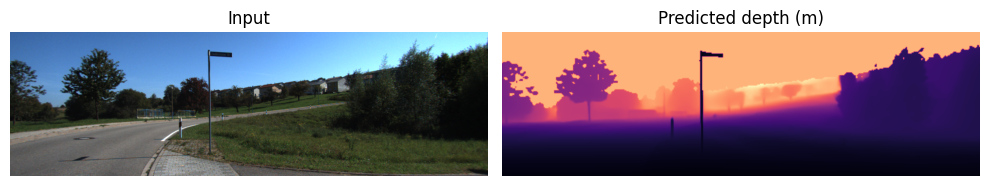

[INFO ] Processed Images Done taking 0.13121294975280762 seconds. Shape:  torch.Size([4, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.5267412662506104 seconds
[INFO ] Conversion to Prediction Done. Time: 0.002186298370361328 seconds
[INFO ] Processed Images Done taking 0.09973430633544922 seconds. Shape:  torch.Size([4, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.5299184322357178 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014879703521728516 seconds
[INFO ] Processed Images Done taking 0.10568714141845703 seconds. Shape:  torch.Size([4, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.5307526588439941 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0014693737030029297 seconds
[INFO ] Processed Images Done taking 0.09937167167663574 seconds. Shape:  torch.Size([4, 3, 154, 504])
[INFO ] Model Forward Pass Done. Time: 0.5307958126068115 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0015025138854980469 seconds
[INFO ] Processed Images 

In [ ]:
#@title [NEW] 12) Generate predicted depth maps and resize them
import json
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR
depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
depth_dir.mkdir(parents=True, exist_ok=True)

# --- collect image paths ---
img_paths = sorted(img_dir.glob('*.png'))
if MAX_FRAMES is not None:
    img_paths = img_paths[:MAX_FRAMES]
if BENCHMARK_ONLY:
    img_paths = img_paths[:BENCHMARK_N_FRAMES]

assert len(img_paths) > 0, f'No images found in {img_dir}'
print('Generating depth for', len(img_paths), 'frames')
print('Saving to', depth_dir)

# --- parse focal length from KITTI calib ---
def read_kitti_calib(calib_path):
    proj = {}
    with open(calib_path, 'r') as f:
        for line in f:
            if ':' not in line:
                continue
            key, values = line.split(':', 1)
            vals = np.fromstring(values.strip(), sep=' ')
            if vals.size == 12:
                proj[key.strip()] = vals.reshape(3, 4)
    return proj

proj = read_kitti_calib(seq_dir / 'calib.txt')
cam_key = 'P2' if USE_COLOR else 'P0'
P = proj[cam_key]
fx = float(P[0, 0])
fy = float(P[1, 1])
focal_px = 0.5 * (fx + fy)
print('Using focal_px =', focal_px)
if DEPTH_BACKEND == 'da3':
    print('DA3 scaling enabled: metric_depth_m = focal_px * net_output / 300.0')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device =', device)
if device.type == 'cpu':
    print('WARNING: You are on CPU. Depth generation will be much slower than on a GPU runtime.')

def save_depth_png(depth_m, dst_path, scale):
    depth_scaled = np.clip(depth_m * scale, 0, 65535).astype(np.uint16)
    cv2.imwrite(str(dst_path), depth_scaled)

def resize_depth_to_shape(depth_m, target_hw):
    target_h, target_w = target_hw
    if depth_m.shape[:2] != (target_h, target_w):
        depth_m = cv2.resize(
            depth_m,
            (target_w, target_h),
            interpolation=cv2.INTER_LINEAR
        )
    return depth_m.astype(np.float32)

preview_saved = False
t0 = time.perf_counter()
frame_times = []

if GENERATE_DEPTH:
    if DEPTH_BACKEND == 'da2':
        from transformers import AutoImageProcessor, AutoModelForDepthEstimation

        image_processor = AutoImageProcessor.from_pretrained(
            str(DEPTH_MODEL_DIR),
            local_files_only=True
        )
        model = AutoModelForDepthEstimation.from_pretrained(
            str(DEPTH_MODEL_DIR),
            local_files_only=True
        )
        model = model.to(device).eval()

        for img_path in tqdm(img_paths, desc='DA2 depth'):
            dst_path = depth_dir / img_path.name
            if dst_path.exists():
                continue

            image = Image.open(img_path).convert('RGB')
            inputs = image_processor(images=image, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}

            t_start = time.perf_counter()
            with torch.no_grad():
                outputs = model(**inputs)
                predicted_depth = outputs.predicted_depth
                prediction = torch.nn.functional.interpolate(
                    predicted_depth.unsqueeze(1),
                    size=image.size[::-1],
                    mode='bicubic',
                    align_corners=False,
                ).squeeze().detach().cpu().numpy().astype(np.float32)
            frame_times.append(time.perf_counter() - t_start)

            # DA2 metric outdoor model outputs metric depth
            depth_m = prediction
            save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

            if SAVE_PREVIEW_IMAGES and not preview_saved:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(image)
                plt.title('Input')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(depth_m, cmap='magma')
                plt.title('Predicted depth (m)')
                plt.axis('off')
                plt.tight_layout()
                plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                plt.show()
                preview_saved = True

    elif DEPTH_BACKEND == 'da3':
        import sys

        da3_src = Path('/content/Depth-Anything-3/src')
        if str(da3_src) not in sys.path:
            sys.path.insert(0, str(da3_src))

        from depth_anything_3.api import DepthAnything3

        temp_rgb_dir = Path('/content') / f'da3_input_{SEQUENCE}_{IMAGE_SUBDIR}'
        temp_rgb_dir.mkdir(parents=True, exist_ok=True)

        # Precompute original image sizes and make RGB copies only as needed
        rgb_paths = []
        orig_sizes = {}

        for img_path in tqdm(img_paths, desc='Preparing RGB copies for DA3'):
            dst_path = depth_dir / img_path.name

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
            if img_bgr is None:
                raise RuntimeError(f'Failed to read image: {img_path}')
            orig_sizes[img_path.name] = img_bgr.shape[:2]  # (H, W)

            rgb_path = temp_rgb_dir / img_path.name
            rgb_paths.append(rgb_path)

            # Skip rewriting temp RGB if it already exists
            if not rgb_path.exists():
                image = Image.open(img_path).convert('RGB')
                image.save(rgb_path)

        model = DepthAnything3.from_pretrained(str(DEPTH_MODEL_DIR))
        model = model.to(device=device)
        model.eval()

        for batch_start in tqdm(range(0, len(rgb_paths), DA3_BATCH_SIZE), desc='DA3 depth'):
            batch_paths = rgb_paths[batch_start:batch_start + DA3_BATCH_SIZE]
            batch_dst = [depth_dir / p.name for p in batch_paths]

            # Skip full batch if every output already exists
            if all(p.exists() for p in batch_dst):
                continue

            run_paths = []
            run_dst = []
            run_sizes = []

            for p, dst_path in zip(batch_paths, batch_dst):
                if dst_path.exists():
                    continue
                run_paths.append(p)
                run_dst.append(dst_path)
                run_sizes.append(orig_sizes[p.name])

            if not run_paths:
                continue

            t_start = time.perf_counter()
            with torch.no_grad():
                prediction = model.inference([str(p) for p in run_paths])
            frame_times.append(time.perf_counter() - t_start)

            # Official DA3 metric conversion:
            # metric_depth_m = focal_px * net_output / 300
            depth_batch = np.asarray(prediction.depth, dtype=np.float32)
            metric_depth_batch = (focal_px * depth_batch) / 300.0

            for depth_m, dst_path, src_path, target_hw in zip(metric_depth_batch, run_dst, run_paths, run_sizes):
                depth_m = resize_depth_to_shape(depth_m, target_hw)
                save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

                if SAVE_PREVIEW_IMAGES and not preview_saved:
                    image = Image.open(src_path)
                    plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.imshow(image)
                    plt.title('Input')
                    plt.axis('off')

                    plt.subplot(1, 2, 2)
                    plt.imshow(depth_m, cmap='magma')
                    plt.title('Predicted depth (m)')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                    plt.show()
                    preview_saved = True
    else:
        raise ValueError(f'Unsupported DEPTH_BACKEND: {DEPTH_BACKEND}')

elapsed = time.perf_counter() - t0
summary = {
    'sequence': SEQUENCE,
    'image_subdir': IMAGE_SUBDIR,
    'depth_backend': DEPTH_BACKEND,
    'depth_model_repo': DEPTH_MODEL_REPO,
    'depth_model_dir': str(DEPTH_MODEL_DIR),
    'num_frames_requested': len(img_paths),
    'num_depth_pngs_present': len([p for p in depth_dir.glob('*.png') if p.name != 'depth_preview.png']),
    'focal_px': focal_px,
    'depth_png_scale': DEPTH_PNG_SCALE,
    'elapsed_total_sec': elapsed,
    'avg_model_inference_sec_per_call': float(np.mean(frame_times)) if frame_times else None,
    'median_model_inference_sec_per_call': float(np.median(frame_times)) if frame_times else None,
}
with open(depth_dir / 'depth_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print('Depth directory:', depth_dir)

Generating depth for 4914 frames
Saving to /content/drive/MyDrive/kitti_depth_anything/99/da3_image_2
Using approximate intrinsics:
fx = 628.0 fy = 642.0 cx = 319.5 cy = 239.5
DA3 scaling enabled: metric_depth_m = focal_px * net_output / 300.0
Torch device = cuda


Preparing RGB copies for DA3:   0%|          | 0/4914 [00:00<?, ?it/s]

[INFO ] using MLP layer as FFN
Loading weights from local directory


DA3 depth:   0%|          | 0/1229 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.08579778671264648 seconds. Shape:  torch.Size([4, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.6653449535369873 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0023987293243408203 seconds


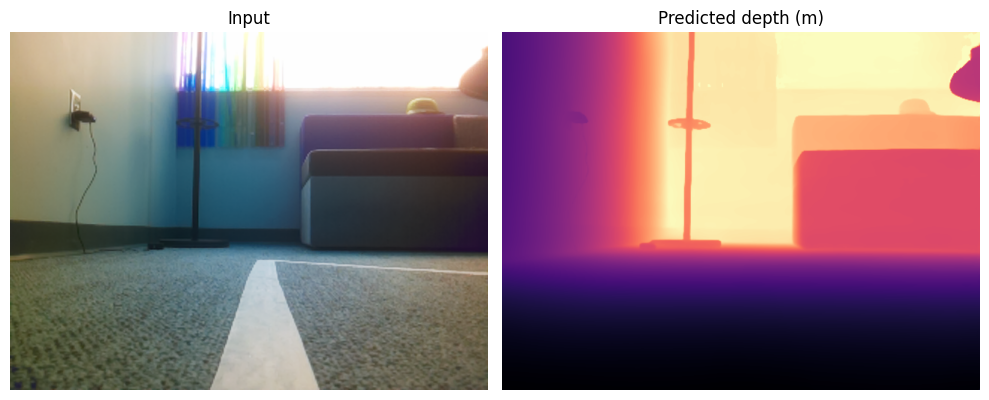

[INFO ] Processed Images Done taking 0.06441140174865723 seconds. Shape:  torch.Size([4, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.4622218608856201 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001984119415283203 seconds
[INFO ] Processed Images Done taking 0.06447863578796387 seconds. Shape:  torch.Size([4, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.471346139907837 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0022912025451660156 seconds
[INFO ] Processed Images Done taking 0.08028864860534668 seconds. Shape:  torch.Size([4, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.4832055568695068 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0022859573364257812 seconds
[INFO ] Processed Images Done taking 0.06832098960876465 seconds. Shape:  torch.Size([4, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.4720966815948486 seconds
[INFO ] Conversion to Prediction Done. Time: 0.002145528793334961 seconds
[INFO ] Processed Images Do

In [ ]:
#@title [ROSBAG] 12) Generate predicted depth maps and resize them
import json
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
img_dir = seq_dir / IMAGE_SUBDIR
depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
depth_dir.mkdir(parents=True, exist_ok=True)

# --- collect image paths ---
img_paths = sorted(img_dir.glob('*.png'))
if MAX_FRAMES is not None:
    img_paths = img_paths[:MAX_FRAMES]
if BENCHMARK_ONLY:
    img_paths = img_paths[:BENCHMARK_N_FRAMES]

assert len(img_paths) > 0, f'No images found in {img_dir}'
print('Generating depth for', len(img_paths), 'frames')
print('Saving to', depth_dir)

# --- approximate camera intrinsics for uncalibrated 640x480 OV5647 data ---
fx = 628.0
fy = 642.0
cx = 319.5
cy = 239.5
focal_px = 0.5 * (fx + fy)

print('Using approximate intrinsics:')
print('fx =', fx, 'fy =', fy, 'cx =', cx, 'cy =', cy)
if DEPTH_BACKEND == 'da3':
    print('DA3 scaling enabled: metric_depth_m = focal_px * net_output / 300.0')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device =', device)
if device.type == 'cpu':
    print('WARNING: You are on CPU. Depth generation will be much slower than on a GPU runtime.')

def save_depth_png(depth_m, dst_path, scale):
    depth_scaled = np.clip(depth_m * scale, 0, 65535).astype(np.uint16)
    cv2.imwrite(str(dst_path), depth_scaled)

def resize_depth_to_shape(depth_m, target_hw):
    target_h, target_w = target_hw
    if depth_m.shape[:2] != (target_h, target_w):
        depth_m = cv2.resize(
            depth_m,
            (target_w, target_h),
            interpolation=cv2.INTER_LINEAR
        )
    return depth_m.astype(np.float32)

preview_saved = False
t0 = time.perf_counter()
frame_times = []

if GENERATE_DEPTH:
    if DEPTH_BACKEND == 'da2':
        from transformers import AutoImageProcessor, AutoModelForDepthEstimation

        image_processor = AutoImageProcessor.from_pretrained(
            str(DEPTH_MODEL_DIR),
            local_files_only=True
        )
        model = AutoModelForDepthEstimation.from_pretrained(
            str(DEPTH_MODEL_DIR),
            local_files_only=True
        )
        model = model.to(device).eval()

        for img_path in tqdm(img_paths, desc='DA2 depth'):
            dst_path = depth_dir / img_path.name
            if dst_path.exists():
                continue

            image = Image.open(img_path).convert('RGB')
            inputs = image_processor(images=image, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}

            t_start = time.perf_counter()
            with torch.no_grad():
                outputs = model(**inputs)
                predicted_depth = outputs.predicted_depth
                prediction = torch.nn.functional.interpolate(
                    predicted_depth.unsqueeze(1),
                    size=image.size[::-1],
                    mode='bicubic',
                    align_corners=False,
                ).squeeze().detach().cpu().numpy().astype(np.float32)
            frame_times.append(time.perf_counter() - t_start)

            # DA2 metric outdoor model outputs metric depth
            depth_m = prediction
            save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

            if SAVE_PREVIEW_IMAGES and not preview_saved:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(image)
                plt.title('Input')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(depth_m, cmap='magma')
                plt.title('Predicted depth (m)')
                plt.axis('off')
                plt.tight_layout()
                plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                plt.show()
                preview_saved = True

    elif DEPTH_BACKEND == 'da3':
        import sys

        da3_src = Path('/content/Depth-Anything-3/src')
        if str(da3_src) not in sys.path:
            sys.path.insert(0, str(da3_src))

        from depth_anything_3.api import DepthAnything3

        temp_rgb_dir = Path('/content') / f'da3_input_{SEQUENCE}_{IMAGE_SUBDIR}'
        temp_rgb_dir.mkdir(parents=True, exist_ok=True)

        # Precompute original image sizes and make RGB copies only as needed
        rgb_paths = []
        orig_sizes = {}

        for img_path in tqdm(img_paths, desc='Preparing RGB copies for DA3'):
            dst_path = depth_dir / img_path.name

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
            if img_bgr is None:
                raise RuntimeError(f'Failed to read image: {img_path}')
            orig_sizes[img_path.name] = img_bgr.shape[:2]  # (H, W)

            rgb_path = temp_rgb_dir / img_path.name
            rgb_paths.append(rgb_path)

            # Skip rewriting temp RGB if it already exists
            if not rgb_path.exists():
                image = Image.open(img_path).convert('RGB')
                image.save(rgb_path)

        model = DepthAnything3.from_pretrained(str(DEPTH_MODEL_DIR))
        model = model.to(device=device)
        model.eval()

        for batch_start in tqdm(range(0, len(rgb_paths), DA3_BATCH_SIZE), desc='DA3 depth'):
            batch_paths = rgb_paths[batch_start:batch_start + DA3_BATCH_SIZE]
            batch_dst = [depth_dir / p.name for p in batch_paths]

            # Skip full batch if every output already exists
            if all(p.exists() for p in batch_dst):
                continue

            run_paths = []
            run_dst = []
            run_sizes = []

            for p, dst_path in zip(batch_paths, batch_dst):
                if dst_path.exists():
                    continue
                run_paths.append(p)
                run_dst.append(dst_path)
                run_sizes.append(orig_sizes[p.name])

            if not run_paths:
                continue

            t_start = time.perf_counter()
            with torch.no_grad():
                prediction = model.inference([str(p) for p in run_paths])
            frame_times.append(time.perf_counter() - t_start)

            # Official DA3 metric conversion:
            # metric_depth_m = focal_px * net_output / 300
            depth_batch = np.asarray(prediction.depth, dtype=np.float32)
            metric_depth_batch = (focal_px * depth_batch) / 300.0

            for depth_m, dst_path, src_path, target_hw in zip(metric_depth_batch, run_dst, run_paths, run_sizes):
                depth_m = resize_depth_to_shape(depth_m, target_hw)
                save_depth_png(depth_m, dst_path, DEPTH_PNG_SCALE)

                if SAVE_PREVIEW_IMAGES and not preview_saved:
                    image = Image.open(src_path)
                    plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.imshow(image)
                    plt.title('Input')
                    plt.axis('off')

                    plt.subplot(1, 2, 2)
                    plt.imshow(depth_m, cmap='magma')
                    plt.title('Predicted depth (m)')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.savefig(depth_dir / 'depth_preview.png', bbox_inches='tight')
                    plt.show()
                    preview_saved = True
    else:
        raise ValueError(f'Unsupported DEPTH_BACKEND: {DEPTH_BACKEND}')

elapsed = time.perf_counter() - t0
summary = {
    'sequence': SEQUENCE,
    'image_subdir': IMAGE_SUBDIR,
    'depth_backend': DEPTH_BACKEND,
    'depth_model_repo': DEPTH_MODEL_REPO,
    'depth_model_dir': str(DEPTH_MODEL_DIR),
    'num_frames_requested': len(img_paths),
    'num_depth_pngs_present': len([p for p in depth_dir.glob('*.png') if p.name != 'depth_preview.png']),
    'focal_px': focal_px,
    'depth_png_scale': DEPTH_PNG_SCALE,
    'elapsed_total_sec': elapsed,
    'avg_model_inference_sec_per_call': float(np.mean(frame_times)) if frame_times else None,
    'median_model_inference_sec_per_call': float(np.median(frame_times)) if frame_times else None,
}
with open(depth_dir / 'depth_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print('Depth directory:', depth_dir)

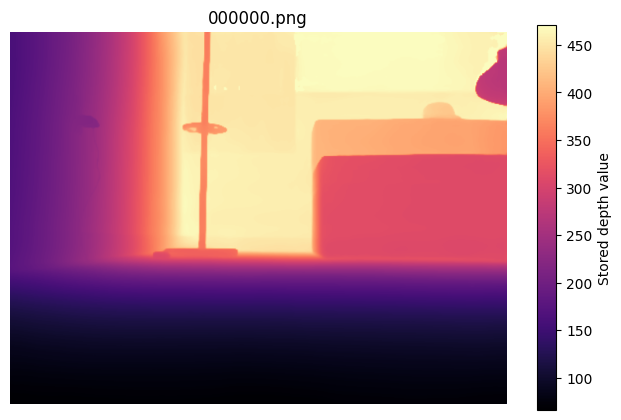

In [ ]:
#@title (optional) Display one saved depth PNG from depth_dir in a human-visible range

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

p = sorted(depth_dir.glob("*.png"))[0]   # first depth image
img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED).astype("float32")

plt.figure(figsize=(8,5))
plt.imshow(img, cmap="magma")
plt.colorbar(label="Stored depth value")
plt.title(p.name)
plt.axis("off")
plt.show()

In [ ]:
#@title 13) Run monocular ORB-SLAM3 baseline
import os, shutil, subprocess
from pathlib import Path

if RUN_MONO_BASELINE:
    orb_root = Path('/content/ORB_SLAM3')
    run_dir = Path('/content') / f'orbslam_mono_run_{SEQUENCE}'
    if run_dir.exists():
        shutil.rmtree(run_dir)
    run_dir.mkdir(parents=True)

    seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE

    yaml_map = {
        '00': 'KITTI00-02.yaml',
        '01': 'KITTI00-02.yaml',
        '02': 'KITTI00-02.yaml',
        '03': 'KITTI03.yaml',
        '04': 'KITTI04-12.yaml',
        '05': 'KITTI04-12.yaml',
        '06': 'KITTI04-12.yaml',
        '07': 'KITTI04-12.yaml',
        '08': 'KITTI04-12.yaml',
        '09': 'KITTI04-12.yaml',
        '10': 'KITTI04-12.yaml',
        '99': 'KITTI_custom_99.yaml',
    }
    yaml_name = yaml_map.get(SEQUENCE, 'KITTI04-12.yaml')
    yaml_path = orb_root / 'Examples' / 'Monocular' / yaml_name

    dest_dir = MONO_RESULTS_ROOT / SEQUENCE
    dest_dir.mkdir(parents=True, exist_ok=True)
    frame_stats_drive_path = dest_dir / 'frame_stats.csv'

    cmd = [
        str(orb_root / 'Examples' / 'Monocular' / 'mono_kitti'),
        str(orb_root / 'Vocabulary' / 'ORBvoc.txt'),
        str(yaml_path),
        str(seq_dir),
    ]
    print('Running:', ' '.join(cmd))
    print('frame_stats.csv will be written to:', frame_stats_drive_path)

    env = os.environ.copy()
    env['ORBSLAM_FRAME_STATS_PATH'] = str(frame_stats_drive_path)

    with open(run_dir / 'run.log', 'w') as logf:
        subprocess.run(
            cmd,
            cwd=run_dir,
            env=env,
            stdout=logf,
            stderr=subprocess.STDOUT,
            check=True
        )

    for name in [
        'CameraTrajectory.txt',
        'KeyFrameTrajectory_Euroc.txt',
        'KeyFrameTrajectory_TUM.txt',
        'run.log',
    ]:
        src = run_dir / name
        if src.exists():
            shutil.copy2(src, dest_dir / name)

    print('Saved mono results to', dest_dir)
    print('frame_stats saved to', frame_stats_drive_path)

Running: /content/ORB_SLAM3/Examples/Monocular/mono_kitti /content/ORB_SLAM3/Vocabulary/ORBvoc.txt /content/ORB_SLAM3/Examples/Monocular/KITTI04-12.yaml /content/drive/MyDrive/kitti_odometry/sequences/04
frame_stats.csv will be written to: /content/drive/MyDrive/orbslam3_kitti_results/04/frame_stats.csv
Saved mono results to /content/drive/MyDrive/orbslam3_kitti_results/04
frame_stats saved to /content/drive/MyDrive/orbslam3_kitti_results/04/frame_stats.csv


In [ ]:

#@title 14) Run RGB-D ORB-SLAM3 with predicted depth
import os, shutil, subprocess
from pathlib import Path

if RUN_RGBD_WITH_PRED_DEPTH:
    orb_root = Path('/content/ORB_SLAM3')
    seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
    depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
    assert depth_dir.exists(), f'Missing depth directory: {depth_dir}'

    run_dir = Path('/content') / f'orbslam_rgbd_preddepth_run_{SEQUENCE}'
    if run_dir.exists():
        shutil.rmtree(run_dir)
    run_dir.mkdir(parents=True)

    cmd = [
        str(orb_root / 'Examples' / 'RGB-D' / 'rgbd_kitti_preddepth'),
        str(orb_root / 'Vocabulary' / 'ORBvoc.txt'),
        str(rgbd_yaml_path),
        str(seq_dir),
        str(depth_dir),
        IMAGE_SUBDIR,
        str(DEPTH_PNG_SCALE),
    ]
    print('Running:', ' '.join(cmd))

    with open(run_dir / 'run.log', 'w') as logf:
        subprocess.run(cmd, cwd=run_dir, stdout=logf, stderr=subprocess.STDOUT, check=True)

    dest_dir = RGBD_RESULTS_ROOT / SEQUENCE
    dest_dir.mkdir(parents=True, exist_ok=True)
    for name in [
        'CameraTrajectory.txt',
        'CameraTrajectory_TUM.txt',
        'CameraTrajectory_KITTI.txt',
        'KeyFrameTrajectory_Euroc.txt',
        'KeyFrameTrajectory_TUM.txt',
        'run.log',
    ]:
        src = run_dir / name
        if src.exists():
            shutil.copy2(src, dest_dir / name)

    print('Saved RGB-D outputs to', dest_dir)
else:
    print('Skipping RGB-D run.')


Running: /content/ORB_SLAM3/Examples/RGB-D/rgbd_kitti_preddepth /content/ORB_SLAM3/Vocabulary/ORBvoc.txt /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_03.yaml /content/drive/MyDrive/kitti_odometry/sequences/03 /content/drive/MyDrive/kitti_depth_anything/03/da3_image_2 image_2 100.0
Saved RGB-D outputs to /content/drive/MyDrive/orbslam3_kitti_rgbd_results/03


In [ ]:

#@title 15.1) Build masked depth directory for weak keyframes only
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

if RUN_RGBD_WEAK_KEYFRAMES:
    seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
    times_file = seq_dir / 'times.txt'
    src_depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
    mono_dir = MONO_RESULTS_ROOT / SEQUENCE

    assert src_depth_dir.exists(), f'Missing source depth dir: {src_depth_dir}'
    assert times_file.exists(), f'Missing times file: {times_file}'

    frame_stats_path = mono_dir / 'frame_stats.csv'
    kf_tum_path = mono_dir / 'KeyFrameTrajectory_TUM.txt'

    if not frame_stats_path.exists():
        raise FileNotFoundError(
            f'Missing {frame_stats_path}. Rerun the mono baseline once with the patched notebook so frame stats get saved.'
        )
    if not kf_tum_path.exists():
        raise FileNotFoundError(f'Missing {kf_tum_path}')

    frame_stats = pd.read_csv(frame_stats_path)
    frame_times = np.loadtxt(times_file).reshape(-1)
    assert len(frame_times) == len(frame_stats), 'times.txt and frame_stats.csv length mismatch'

    # --- mark mono keyframes by nearest timestamp match ---
    kf_tum = pd.read_csv(
        kf_tum_path,
        sep=r'\s+',
        comment='#',
        header=None,
        usecols=[0],
        names=['timestamp'],
        engine='python',
    )
    kf_ts = kf_tum['timestamp'].to_numpy(dtype=float)

    is_keyframe = np.zeros(len(frame_times), dtype=bool)
    kf_match_rows = []

    for ts in kf_ts:
        idx = int(np.argmin(np.abs(frame_times - ts)))
        err = float(abs(frame_times[idx] - ts))
        if err <= KEYFRAME_TIMESTAMP_TOL:
            is_keyframe[idx] = True
            kf_match_rows.append((idx, frame_times[idx], ts, err))
        else:
            kf_match_rows.append((idx, frame_times[idx], ts, err))

    frame_stats['is_keyframe'] = is_keyframe

    valid_counts = frame_stats.loc[frame_stats['tracked_mappoints'] > 0, 'tracked_mappoints']
    if len(valid_counts) == 0:
        raise RuntimeError('No positive tracked_mappoints found in frame_stats.csv')

    weak_threshold = float(valid_counts.quantile(WEAK_TRACKED_POINTS_PERCENTILE))
    frame_stats['is_weak'] = frame_stats['tracked_mappoints'] <= weak_threshold
    frame_stats['use_depth'] = frame_stats['is_keyframe'] & frame_stats['is_weak']

    weak_indices = set(frame_stats.index[frame_stats['use_depth']].tolist())

    weak_tag = f'weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}'
    weak_depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}_{weak_tag}'

    if weak_depth_dir.exists() and REBUILD_WEAKKF_DEPTH_DIR:
        shutil.rmtree(weak_depth_dir)
    weak_depth_dir.mkdir(parents=True, exist_ok=True)

    # Save selection metadata
    frame_stats.to_csv(weak_depth_dir / 'weak_keyframe_selection.csv', index=False)
    pd.DataFrame(kf_match_rows, columns=['matched_frame_idx', 'frame_timestamp', 'kf_timestamp', 'abs_error_s']) \
        .to_csv(weak_depth_dir / 'keyframe_timestamp_matches.csv', index=False)

    summary = {
        'sequence': SEQUENCE,
        'image_subdir': IMAGE_SUBDIR,
        'source_depth_dir': str(src_depth_dir),
        'weak_depth_dir': str(weak_depth_dir),
        'weak_tracked_points_percentile': float(WEAK_TRACKED_POINTS_PERCENTILE),
        'weak_threshold_tracked_mappoints': weak_threshold,
        'n_frames': int(len(frame_stats)),
        'n_keyframes': int(frame_stats['is_keyframe'].sum()),
        'n_weak_frames': int(frame_stats['is_weak'].sum()),
        'n_weak_keyframes': int(frame_stats['use_depth'].sum()),
    }
    print(summary)

    # Create a single zero-depth template and copy it for non-selected frames
    src_depth_files = sorted(src_depth_dir.glob('*.png'))
    assert src_depth_files, f'No PNG depth files found in {src_depth_dir}'

    first_depth = cv2.imread(str(src_depth_files[0]), cv2.IMREAD_UNCHANGED)
    if first_depth is None:
        raise RuntimeError(f'Failed to read depth PNG: {src_depth_files[0]}')

    zero_template = np.zeros_like(first_depth)
    zero_template_path = weak_depth_dir / '_zero_template.png'
    ok = cv2.imwrite(str(zero_template_path), zero_template)
    if not ok:
        raise RuntimeError(f'Failed to write zero template: {zero_template_path}')

    for src_path in src_depth_files:
        if not src_path.stem.isdigit():
            print(f"Skipping non-frame depth PNG: {src_path.name}")
            continue

        idx = int(src_path.stem)
        dst_path = weak_depth_dir / src_path.name
        if idx in weak_indices:
            shutil.copy2(src_path, dst_path)
        else:
            shutil.copy2(zero_template_path, dst_path)

    print('Saved weak-keyframe masked depth directory to', weak_depth_dir)
else:
    print('Skipping weak-keyframe depth directory build.')


{'sequence': '99', 'image_subdir': 'image_2', 'source_depth_dir': '/content/drive/MyDrive/kitti_depth_anything/99/da3_image_2', 'weak_depth_dir': '/content/drive/MyDrive/kitti_depth_anything/99/da3_image_2_weakkf_p03', 'weak_tracked_points_percentile': 0.03, 'weak_threshold_tracked_mappoints': 82.0, 'n_frames': 4914, 'n_keyframes': 852, 'n_weak_frames': 1566, 'n_weak_keyframes': 52}
Skipping non-frame depth PNG: depth_preview.png
Saved weak-keyframe masked depth directory to /content/drive/MyDrive/kitti_depth_anything/99/da3_image_2_weakkf_p03


In [ ]:

#@title 15.2) Run RGB-D ORB-SLAM3 with predicted depth on weak keyframes only
import os, shutil, subprocess
from pathlib import Path

if RUN_RGBD_WEAK_KEYFRAMES:
    orb_root = Path('/content/ORB_SLAM3')
    seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
    weak_tag = f'weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}'
    weak_depth_dir = DEPTH_ROOT / SEQUENCE / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}_{weak_tag}'
    assert weak_depth_dir.exists(), f'Missing weak-keyframe depth directory: {weak_depth_dir}'

    run_dir = Path('/content') / f'orbslam_rgbd_weakkf_run_{SEQUENCE}'
    if run_dir.exists():
        shutil.rmtree(run_dir)
    run_dir.mkdir(parents=True)

    cmd = [
        str(orb_root / 'Examples' / 'RGB-D' / 'rgbd_kitti_preddepth'),
        str(orb_root / 'Vocabulary' / 'ORBvoc.txt'),
        str(rgbd_yaml_path),
        str(seq_dir),
        str(weak_depth_dir),
        IMAGE_SUBDIR,
        str(DEPTH_PNG_SCALE),
    ]
    print('Running:', ' '.join(cmd))

    with open(run_dir / 'run.log', 'w') as logf:
        subprocess.run(cmd, cwd=run_dir, stdout=logf, stderr=subprocess.STDOUT, check=True)

    dest_dir = RGBD_WEAKKF_RESULTS_ROOT / SEQUENCE / weak_tag
    dest_dir.mkdir(parents=True, exist_ok=True)
    for name in [
        'CameraTrajectory.txt',
        'CameraTrajectory_TUM.txt',
        'CameraTrajectory_KITTI.txt',
        'KeyFrameTrajectory_Euroc.txt',
        'KeyFrameTrajectory_TUM.txt',
        'run.log',
    ]:
        src = run_dir / name
        if src.exists():
            shutil.copy2(src, dest_dir / name)

    # Copy the selection metadata alongside results for easy comparison later
    for name in ['weak_keyframe_selection.csv', 'keyframe_timestamp_matches.csv']:
        src = weak_depth_dir / name
        if src.exists():
            shutil.copy2(src, dest_dir / name)

    print('Saved weak-keyframe RGB-D outputs to', dest_dir)
else:
    print('Skipping weak-keyframe RGB-D run.')


Running: /content/ORB_SLAM3/Examples/RGB-D/rgbd_kitti_preddepth /content/ORB_SLAM3/Vocabulary/ORBvoc.txt /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_99.yaml /content/drive/MyDrive/kitti_odometry/sequences/99 /content/drive/MyDrive/kitti_depth_anything/99/da3_image_2_weakkf_p03 image_2 100.0
Saved weak-keyframe RGB-D outputs to /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/weakkf_p03


In [ ]:
#@title 15.3) Build and run all-zero depth control using the exact working YAML from prior RGB-D runs
RUN_ZERO_DEPTH_SEQUENCE = SEQUENCE  # change directly if needed
ZERO_DEPTH_TAG = "allzero_control"

import re
import shutil
import subprocess
from pathlib import Path

import cv2
import numpy as np

seq = str(RUN_ZERO_DEPTH_SEQUENCE).zfill(2)
weak_tag = f"weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}"

orb_root = Path('/content/ORB_SLAM3')
seq_dir = KITTI_ROOT / 'sequences' / seq
src_depth_dir = DEPTH_ROOT / seq / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
zero_depth_dir = DEPTH_ROOT / seq / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}_{ZERO_DEPTH_TAG}'

rgbd_dir = RGBD_RESULTS_ROOT / seq
weakkf_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / weak_tag

# -------------------------------------------------
# 1) Create all-zero depth folder
# -------------------------------------------------
assert src_depth_dir.exists(), f"Missing source depth dir: {src_depth_dir}"
src_depth_files = sorted(
    p for p in src_depth_dir.glob('*.png')
    if p.stem.isdigit()
)
assert src_depth_files, f"No numbered PNG depth files found in {src_depth_dir}"

if zero_depth_dir.exists():
    shutil.rmtree(zero_depth_dir)
zero_depth_dir.mkdir(parents=True, exist_ok=True)

first_depth = cv2.imread(str(src_depth_files[0]), cv2.IMREAD_UNCHANGED)
assert first_depth is not None, f"Failed to read {src_depth_files[0]}"

zero_template = np.zeros_like(first_depth)
zero_template_path = zero_depth_dir / "_zero_template.png"
ok = cv2.imwrite(str(zero_template_path), zero_template)
assert ok, f"Failed to write {zero_template_path}"

for src_path in src_depth_files:
    shutil.copy2(zero_template_path, zero_depth_dir / src_path.name)

print("Created all-zero depth folder:", zero_depth_dir)
print("Number of frames:", len(src_depth_files))
print("Depth dtype:", zero_template.dtype, "shape:", zero_template.shape)

# -------------------------------------------------
# 2) Recover the exact working YAML path
# -------------------------------------------------
def extract_yaml_from_log(log_path: Path):
    if not log_path.exists():
        return None
    txt = log_path.read_text(errors='ignore')
    m = re.search(r'Loading settings from\s+([^\n\r]+)', txt)
    if m:
        p = Path(m.group(1).strip())
        if p.exists():
            return p
    return None

yaml_candidates = []

# First choice: parse successful RGB-D logs
for log_path in [
    rgbd_dir / 'run.log',
    weakkf_dir / 'run.log',
]:
    y = extract_yaml_from_log(log_path)
    if y is not None:
        yaml_candidates.append(y)

# Second choice: notebook globals if they exist
for var_name in [
    'RGBD_YAML_PATH',
    'rgbd_yaml_path',
    'yaml_path',
    'YAML_PATH',
]:
    if var_name in globals():
        try:
            p = Path(globals()[var_name])
            if p.exists():
                yaml_candidates.append(p)
        except Exception:
            pass

# Third choice: common likely locations
for p in [
    orb_root / 'Examples' / 'RGB-D' / f'KITTI_RGBD_{seq}.yaml',
    orb_root / 'Examples' / 'Monocular' / 'KITTI04-12.yaml',
    orb_root / 'Examples' / 'Monocular' / 'KITTI00-02.yaml',
    orb_root / 'Examples' / 'Monocular' / 'KITTI03.yaml',
]:
    if p.exists():
        yaml_candidates.append(p)

# Deduplicate while preserving order
seen = set()
yaml_candidates = [p for p in yaml_candidates if not (str(p) in seen or seen.add(str(p)))]

assert yaml_candidates, "Could not locate any candidate YAML paths"

yaml_path = yaml_candidates[0]
print("Using YAML:", yaml_path)

# -------------------------------------------------
# 3) Run RGB-D with all-zero depth
# -------------------------------------------------
run_dir = Path('/content') / f'orbslam_rgbd_zero_control_{seq}'
if run_dir.exists():
    shutil.rmtree(run_dir)
run_dir.mkdir(parents=True)

zero_results_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / ZERO_DEPTH_TAG
zero_results_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    str(orb_root / 'Examples' / 'RGB-D' / 'rgbd_kitti_preddepth'),
    str(orb_root / 'Vocabulary' / 'ORBvoc.txt'),
    str(yaml_path),
    str(seq_dir),
    str(zero_depth_dir),
    str(IMAGE_SUBDIR),
    str(DEPTH_PNG_SCALE),
]

print("\nRunning command:")
print(" ".join(cmd))
print("Results dir:", zero_results_dir)

log_path = run_dir / 'run.log'
with open(log_path, 'w') as logf:
    proc = subprocess.run(
        cmd,
        cwd=run_dir,
        stdout=logf,
        stderr=subprocess.STDOUT,
        check=False
    )

print("\nReturn code:", proc.returncode)

if proc.returncode != 0:
    print("\n--- run.log tail ---\n")
    print(log_path.read_text(errors='ignore')[-12000:])
    raise RuntimeError(f"rgbd_kitti_preddepth failed with exit code {proc.returncode}")

for name in [
    'CameraTrajectory.txt',
    'CameraTrajectory_TUM.txt',
    'CameraTrajectory_KITTI.txt',
    'KeyFrameTrajectory_Euroc.txt',
    'KeyFrameTrajectory_TUM.txt',
    'run.log',
]:
    src = run_dir / name
    if src.exists():
        shutil.copy2(src, zero_results_dir / name)

print("\nFinished zero-depth control run.")
print("Saved outputs to:", zero_results_dir)
print("Log saved to:", zero_results_dir / 'run.log')

Created all-zero depth folder: /content/drive/MyDrive/kitti_depth_anything/04/da3_image_2_allzero_control
Number of frames: 271
Depth dtype: uint16 shape: (370, 1226)
Using YAML: /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_04.yaml

Running command:
/content/ORB_SLAM3/Examples/RGB-D/rgbd_kitti_preddepth /content/ORB_SLAM3/Vocabulary/ORBvoc.txt /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_04.yaml /content/drive/MyDrive/kitti_odometry/sequences/04 /content/drive/MyDrive/kitti_depth_anything/04/da3_image_2_allzero_control image_2 100.0
Results dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/allzero_control

Return code: 0

Finished zero-depth control run.
Saved outputs to: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/allzero_control
Log saved to: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/allzero_control/run.log


In [ ]:
#@title 15.4) Build and run every-Nth-frame real-depth control
RUN_NTH_SEQUENCE = SEQUENCE   # change directly if needed
NTH_FRAME_STEP = 5            # e.g. 2, 3, 5, 10

import re
import shutil
import subprocess
from pathlib import Path

import cv2
import numpy as np

seq = str(RUN_NTH_SEQUENCE).zfill(2)
nth_tag = f"every{NTH_FRAME_STEP}th_realdepth"

orb_root = Path('/content/ORB_SLAM3')
seq_dir = KITTI_ROOT / 'sequences' / seq
src_depth_dir = DEPTH_ROOT / seq / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}'
nth_depth_dir = DEPTH_ROOT / seq / f'{DEPTH_BACKEND}_{IMAGE_SUBDIR}_{nth_tag}'

rgbd_dir = RGBD_RESULTS_ROOT / seq
weak_tag = f"weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}"
weakkf_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / weak_tag

assert src_depth_dir.exists(), f"Missing source depth dir: {src_depth_dir}"

src_depth_files = sorted(
    p for p in src_depth_dir.glob('*.png')
    if p.stem.isdigit()
)
assert src_depth_files, f"No numbered PNG depth files found in {src_depth_dir}"

if nth_depth_dir.exists():
    shutil.rmtree(nth_depth_dir)
nth_depth_dir.mkdir(parents=True, exist_ok=True)

first_depth = cv2.imread(str(src_depth_files[0]), cv2.IMREAD_UNCHANGED)
assert first_depth is not None, f"Failed to read {src_depth_files[0]}"

zero_template = np.zeros_like(first_depth)
zero_template_path = nth_depth_dir / "_zero_template.png"
ok = cv2.imwrite(str(zero_template_path), zero_template)
assert ok, f"Failed to write {zero_template_path}"

kept = 0
masked = 0

for src_path in src_depth_files:
    idx = int(src_path.stem)
    dst_path = nth_depth_dir / src_path.name
    if idx % NTH_FRAME_STEP == 0:
        shutil.copy2(src_path, dst_path)
        kept += 1
    else:
        shutil.copy2(zero_template_path, dst_path)
        masked += 1

print("Created every-Nth depth folder:", nth_depth_dir)
print("Kept real depth frames:", kept)
print("Masked frames:", masked)
print("Depth dtype:", zero_template.dtype, "shape:", zero_template.shape)

# -------------------------------------------------
# recover the exact working YAML path from prior successful runs
# -------------------------------------------------
def extract_yaml_from_log(log_path: Path):
    if not log_path.exists():
        return None
    txt = log_path.read_text(errors='ignore')
    m = re.search(r'Loading settings from\s+([^\n\r]+)', txt)
    if m:
        p = Path(m.group(1).strip())
        if p.exists():
            return p
    return None

yaml_candidates = []

for log_path in [
    rgbd_dir / 'run.log',
    weakkf_dir / 'run.log',
]:
    y = extract_yaml_from_log(log_path)
    if y is not None:
        yaml_candidates.append(y)

for var_name in [
    'RGBD_YAML_PATH',
    'rgbd_yaml_path',
    'yaml_path',
    'YAML_PATH',
]:
    if var_name in globals():
        try:
            p = Path(globals()[var_name])
            if p.exists():
                yaml_candidates.append(p)
        except Exception:
            pass

seen = set()
yaml_candidates = [p for p in yaml_candidates if not (str(p) in seen or seen.add(str(p)))]
assert yaml_candidates, "Could not locate a working RGB-D YAML path"

yaml_path = yaml_candidates[0]
print("Using YAML:", yaml_path)

# -------------------------------------------------
# run RGB-D with every-Nth-frame real depth
# -------------------------------------------------
run_dir = Path('/content') / f'orbslam_rgbd_{nth_tag}_{seq}'
if run_dir.exists():
    shutil.rmtree(run_dir)
run_dir.mkdir(parents=True)

nth_results_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / nth_tag
nth_results_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    str(orb_root / 'Examples' / 'RGB-D' / 'rgbd_kitti_preddepth'),
    str(orb_root / 'Vocabulary' / 'ORBvoc.txt'),
    str(yaml_path),
    str(seq_dir),
    str(nth_depth_dir),
    str(IMAGE_SUBDIR),
    str(DEPTH_PNG_SCALE),
]

print("\nRunning command:")
print(" ".join(cmd))
print("Results dir:", nth_results_dir)

log_path = run_dir / 'run.log'
with open(log_path, 'w') as logf:
    proc = subprocess.run(
        cmd,
        cwd=run_dir,
        stdout=logf,
        stderr=subprocess.STDOUT,
        check=False
    )

print("\nReturn code:", proc.returncode)

if proc.returncode != 0:
    print("\n--- run.log tail ---\n")
    print(log_path.read_text(errors='ignore')[-12000:])
    raise RuntimeError(f"rgbd_kitti_preddepth failed with exit code {proc.returncode}")

for name in [
    'CameraTrajectory.txt',
    'CameraTrajectory_TUM.txt',
    'CameraTrajectory_KITTI.txt',
    'KeyFrameTrajectory_Euroc.txt',
    'KeyFrameTrajectory_TUM.txt',
    'run.log',
]:
    src = run_dir / name
    if src.exists():
        shutil.copy2(src, nth_results_dir / name)

print("\nFinished every-Nth-frame control run.")
print("Saved outputs to:", nth_results_dir)
print("Log saved to:", nth_results_dir / 'run.log')

Created every-Nth depth folder: /content/drive/MyDrive/kitti_depth_anything/99/da3_image_2_every5th_realdepth
Kept real depth frames: 983
Masked frames: 3931
Depth dtype: uint16 shape: (480, 640)
Using YAML: /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_99.yaml

Running command:
/content/ORB_SLAM3/Examples/RGB-D/rgbd_kitti_preddepth /content/ORB_SLAM3/Vocabulary/ORBvoc.txt /content/ORB_SLAM3/Examples/RGB-D/KITTI_preddepth_99.yaml /content/drive/MyDrive/kitti_odometry/sequences/99 /content/drive/MyDrive/kitti_depth_anything/99/da3_image_2_every5th_realdepth image_2 100.0
Results dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/every5th_realdepth

Return code: 0

Finished every-Nth-frame control run.
Saved outputs to: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/every5th_realdepth
Log saved to: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/every5th_realdepth/run.log



## Evaluation



No mono trajectory found at /content/drive/MyDrive/orbslam3_kitti_results/03/CameraTrajectory_TUM.txt
{
  "sequence": "03",
  "image_subdir": "image_2",
  "depth_backend": "da3",
  "rgbd_preddepth": {
    "traj_file": "/content/drive/MyDrive/orbslam3_kitti_rgbd_results/03/CameraTrajectory_TUM.txt",
    "matched_points": 801,
    "track_fraction": 1.0,
    "sim3_scale": 0.4576865512648709,
    "sim3_rmse_m": 2.4744401739856996,
    "sim3_mae_m": 2.1604500749817213,
    "se3_rmse_m": 201.22239703388837,
    "se3_mae_m": 180.4049316839111
  }
}


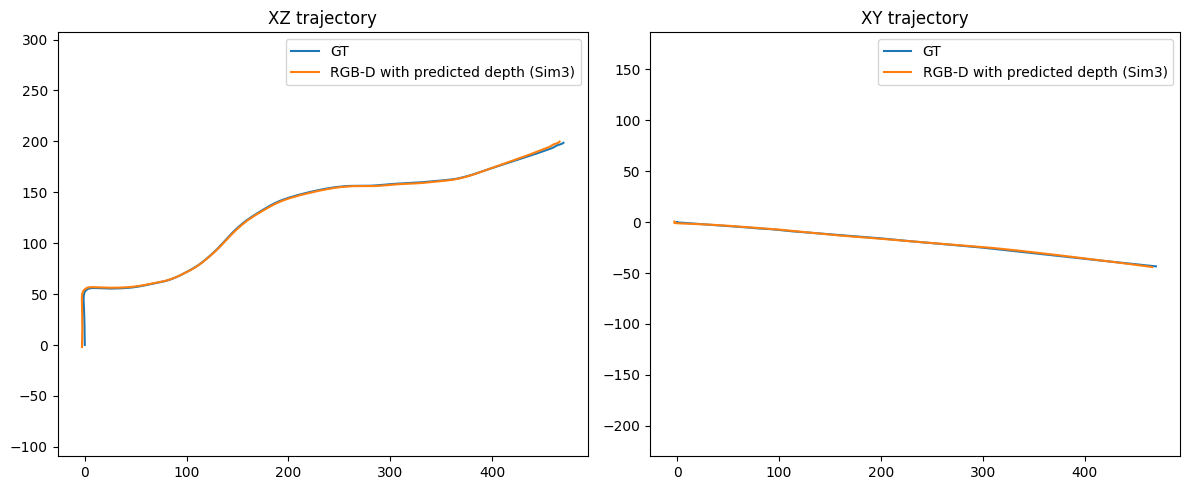

Saved comparison plot to /content/drive/MyDrive/orbslam3_kitti_rgbd_results/03/trajectory_compare_sim3.png
Saved comparison metrics to /content/drive/MyDrive/orbslam3_kitti_rgbd_results/03/metrics_compare.json


In [ ]:

#@title 16) Evaluate monocular vs depth-augmented trajectories + save to drive
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

seq_dir = KITTI_ROOT / 'sequences' / SEQUENCE
pose_file = KITTI_ROOT / 'poses' / f'{SEQUENCE}.txt'
times_file = seq_dir / 'times.txt'

gt_raw = np.loadtxt(pose_file)  # Nx12
gt_xyz = gt_raw.reshape(-1, 3, 4)[:, :, 3]
times = np.loadtxt(times_file).reshape(-1)

mono_dir = MONO_RESULTS_ROOT / SEQUENCE
rgbd_dir = RGBD_RESULTS_ROOT / SEQUENCE

mono_traj_file = mono_dir / 'CameraTrajectory_TUM.txt'
rgbd_traj_file = rgbd_dir / 'CameraTrajectory_TUM.txt'

def load_euroc_xyz(traj_file):
    traj = np.loadtxt(traj_file)
    if traj.ndim == 1:
        traj = traj[None, :]
    assert traj.shape[1] >= 4, f'Unexpected trajectory shape: {traj.shape}'
    pred_t = traj[:, 0]
    if pred_t[0] > 1e6:
        pred_t = pred_t / 1e9
    pred_xyz = traj[:, 1:4]
    return pred_t, pred_xyz

def match_to_kitti_frames(pred_t, pred_xyz, times, gt_xyz):
    frame_idx = np.searchsorted(times, pred_t, side='left')
    frame_idx = np.clip(frame_idx, 0, len(times) - 1)

    better_idx = []
    for i, t in enumerate(pred_t):
        j = frame_idx[i]
        candidates = [j]
        if j > 0:
            candidates.append(j - 1)
        best = min(candidates, key=lambda k: abs(times[k] - t))
        better_idx.append(best)
    frame_idx = np.array(better_idx, dtype=int)

    unique_mask = np.ones(len(frame_idx), dtype=bool)
    seen = set()
    for i, idx in enumerate(frame_idx):
        if idx in seen:
            unique_mask[i] = False
        else:
            seen.add(idx)

    frame_idx = frame_idx[unique_mask]
    pred_xyz = pred_xyz[unique_mask]
    gt_match = gt_xyz[frame_idx]
    return pred_xyz, gt_match, frame_idx

def umeyama_alignment(X, Y, with_scale=True):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    mx = X.mean(axis=0)
    my = Y.mean(axis=0)
    Xc = X - mx
    Yc = Y - my
    cov = (Yc.T @ Xc) / X.shape[0]
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        scale = np.trace(np.diag(D) @ S) / var_X
    else:
        scale = 1.0
    t = my - scale * (R @ mx)
    return scale, R, t

def evaluate_traj(traj_file, label):
    pred_t, pred_xyz = load_euroc_xyz(traj_file)
    pred_xyz, gt_match, frame_idx = match_to_kitti_frames(pred_t, pred_xyz, times, gt_xyz)
    assert len(pred_xyz) >= 5, f'{label}: too few matched points ({len(pred_xyz)})'

    s_sim3, R_sim3, t_sim3 = umeyama_alignment(pred_xyz, gt_match, with_scale=True)
    pred_sim3 = (s_sim3 * (R_sim3 @ pred_xyz.T)).T + t_sim3
    err_sim3 = np.linalg.norm(pred_sim3 - gt_match, axis=1)

    s_se3, R_se3, t_se3 = umeyama_alignment(pred_xyz, gt_match, with_scale=False)
    pred_se3 = (s_se3 * (R_se3 @ pred_xyz.T)).T + t_se3
    err_se3 = np.linalg.norm(pred_se3 - gt_match, axis=1)

    return {
        'label': label,
        'traj_file': str(traj_file),
        'matched_points': int(len(gt_match)),
        'track_fraction': float(len(gt_match) / len(gt_xyz)),
        'sim3_scale': float(s_sim3),
        'sim3_rmse_m': float(np.sqrt(np.mean(err_sim3 ** 2))),
        'sim3_mae_m': float(np.mean(err_sim3)),
        'se3_rmse_m': float(np.sqrt(np.mean(err_se3 ** 2))),
        'se3_mae_m': float(np.mean(err_se3)),
        'gt_match': gt_match,
        'pred_sim3': pred_sim3,
        'pred_se3': pred_se3,
    }

results = {}
if mono_traj_file.exists():
    results['mono'] = evaluate_traj(mono_traj_file, 'Monocular ORB-SLAM3')
else:
    print('No mono trajectory found at', mono_traj_file)

if rgbd_traj_file.exists():
    results['rgbd_preddepth'] = evaluate_traj(rgbd_traj_file, 'RGB-D with predicted depth')
else:
    print('No RGB-D trajectory found at', rgbd_traj_file)

assert results, 'No trajectories found to evaluate.'

compare_out = {
    'sequence': SEQUENCE,
    'image_subdir': IMAGE_SUBDIR,
    'depth_backend': DEPTH_BACKEND,
}

for key, res in results.items():
    compare_out[key] = {
        'traj_file': res['traj_file'],
        'matched_points': res['matched_points'],
        'track_fraction': res['track_fraction'],
        'sim3_scale': res['sim3_scale'],
        'sim3_rmse_m': res['sim3_rmse_m'],
        'sim3_mae_m': res['sim3_mae_m'],
        'se3_rmse_m': res['se3_rmse_m'],
        'se3_mae_m': res['se3_mae_m'],
    }

print(json.dumps(compare_out, indent=2))

# --- Plot XZ view using Sim3-aligned trajectories for side-by-side comparison ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 2], label='GT')
for key, res in results.items():
    plt.plot(res['pred_sim3'][:, 0], res['pred_sim3'][:, 2], label=f'{res["label"]} (Sim3)')
plt.title('XZ trajectory')
plt.axis('equal')
plt.legend()

# --- Plot XY view ---
plt.subplot(1, 2, 2)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 1], label='GT')
for key, res in results.items():
    plt.plot(res['pred_sim3'][:, 0], res['pred_sim3'][:, 1], label=f'{res["label"]} (Sim3)')
plt.title('XY trajectory')
plt.axis('equal')
plt.legend()

plt.tight_layout()
plot_path = RGBD_RESULTS_ROOT / SEQUENCE / 'trajectory_compare_sim3.png'
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

with open(RGBD_RESULTS_ROOT / SEQUENCE / 'metrics_compare.json', 'w') as f:
    json.dump(compare_out, f, indent=2)

print('Saved comparison plot to', plot_path)
print('Saved comparison metrics to', RGBD_RESULTS_ROOT / SEQUENCE / 'metrics_compare.json')


Mono dir: /content/drive/MyDrive/orbslam3_kitti_results/03 True
RGB-D dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/03 True
Mono traj: /content/drive/MyDrive/orbslam3_kitti_results/03/CameraTrajectory.txt True
RGB-D traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/03/CameraTrajectory_TUM.txt True
GT poses: /content/drive/MyDrive/kitti_odometry/poses/03.txt True
Times: /content/drive/MyDrive/kitti_odometry/sequences/03/times.txt True
{
  "sequence": "03",
  "mono": {
    "traj_file": "/content/drive/MyDrive/orbslam3_kitti_results/03/CameraTrajectory.txt",
    "n_poses": 800,
    "rmse_m": 0.8014484236452085,
    "mean_m": 0.6235575114439472,
    "median_m": 0.5389580569632462,
    "max_m": 3.952110956564217,
    "scale": 15.18391750259003
  },
  "rgbd_preddepth": {
    "traj_file": "/content/drive/MyDrive/orbslam3_kitti_rgbd_results/03/CameraTrajectory_TUM.txt",
    "n_poses": 801,
    "rmse_m": 2.4744401739856996,
    "mean_m": 2.1604500749817213,
    "median_m": 1.89

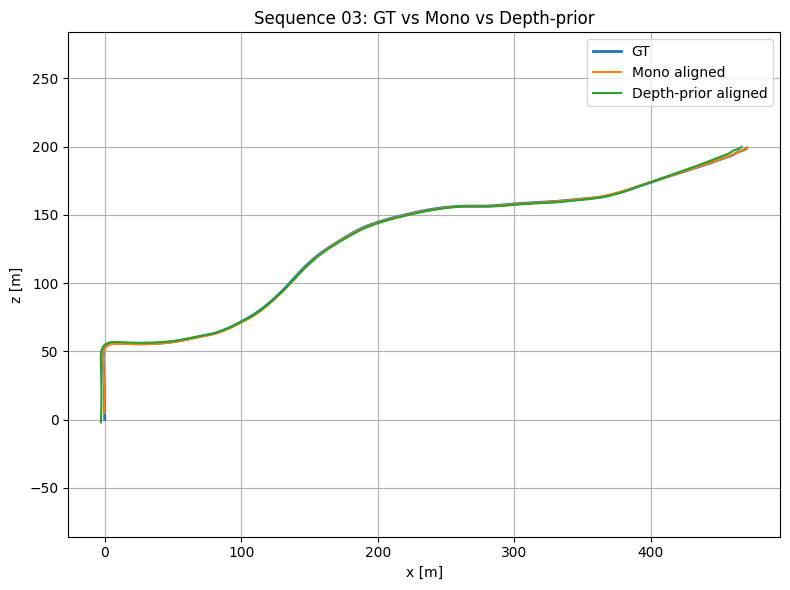

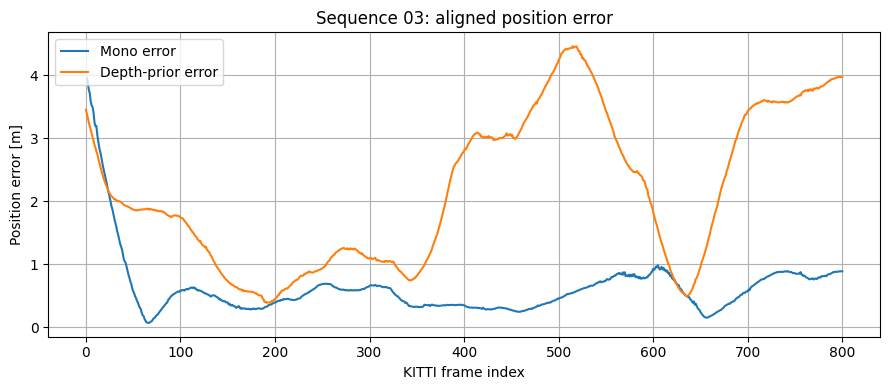

Saved comparison outputs to: /content/drive/MyDrive/orbslam3_compare_results/03


In [ ]:
#@title 16.2) Compare GT vs baseline mono vs depth-prior RGB-D + save to drive
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

seq = SEQUENCE

mono_dir = MONO_RESULTS_ROOT / seq
rgbd_dir = RGBD_RESULTS_ROOT / seq
gt_pose_file = KITTI_ROOT / 'poses' / f'{seq}.txt'
times_file = KITTI_ROOT / 'sequences' / seq / 'times.txt'

mono_tum = mono_dir / 'CameraTrajectory_TUM.txt'
mono_euroc = mono_dir / 'CameraTrajectory.txt'
rgbd_tum = rgbd_dir / 'CameraTrajectory_TUM.txt'
rgbd_euroc = rgbd_dir / 'CameraTrajectory.txt'

mono_traj_file = mono_tum if mono_tum.exists() else mono_euroc
rgbd_traj_file = rgbd_tum if rgbd_tum.exists() else rgbd_euroc

print("Mono dir:", mono_dir, mono_dir.exists())
print("RGB-D dir:", rgbd_dir, rgbd_dir.exists())
print("Mono traj:", mono_traj_file, mono_traj_file.exists())
print("RGB-D traj:", rgbd_traj_file, rgbd_traj_file.exists())
print("GT poses:", gt_pose_file, gt_pose_file.exists())
print("Times:", times_file, times_file.exists())

assert gt_pose_file.exists(), f"Missing GT poses: {gt_pose_file}"
assert times_file.exists(), f"Missing times file: {times_file}"
assert mono_traj_file.exists(), f"Missing mono trajectory: {mono_traj_file}"
assert rgbd_traj_file.exists(), f"Missing RGB-D trajectory: {rgbd_traj_file}"


def load_kitti_gt_xyz(pose_file: Path):
    arr = np.loadtxt(pose_file)
    if arr.ndim == 1:
        arr = arr[None, :]
    mats = arr.reshape(-1, 3, 4)
    xyz = mats[:, :, 3]
    return xyz


def load_times(times_file: Path):
    return np.loadtxt(times_file)


def load_traj_xyz_auto(traj_file: Path):
    arr = np.loadtxt(traj_file)
    if arr.ndim == 1:
        arr = arr[None, :]

    t = arr[:, 0].astype(float)
    xyz = arr[:, 1:4].astype(float)

    # If timestamps look like nanoseconds, convert to seconds.
    # KITTI odometry sequences are on the order of a few hundred seconds.
    if np.nanmax(t) > 1e6:
        t = t / 1e9

    return t, xyz


def match_to_kitti_frames(pred_t, pred_xyz, kitti_times, gt_xyz):
    idx = np.searchsorted(kitti_times, pred_t)
    idx = np.clip(idx, 0, len(kitti_times) - 1)

    prev_idx = np.clip(idx - 1, 0, len(kitti_times) - 1)
    use_prev = np.abs(kitti_times[prev_idx] - pred_t) < np.abs(kitti_times[idx] - pred_t)
    idx[use_prev] = prev_idx[use_prev]

    seen = {}
    for i, j in enumerate(idx):
        err = abs(kitti_times[j] - pred_t[i])
        if j not in seen or err < seen[j][0]:
            seen[j] = (err, i)

    keep_pred_idx = np.array(sorted(v[1] for v in seen.values()), dtype=int)
    keep_gt_idx = idx[keep_pred_idx]

    pred_xyz_matched = pred_xyz[keep_pred_idx]
    gt_xyz_matched = gt_xyz[keep_gt_idx]
    return pred_xyz_matched, gt_xyz_matched, keep_gt_idx


def umeyama_alignment(X, Y, with_scale=True):
    assert X.shape == Y.shape
    n = X.shape[0]

    mean_X = X.mean(axis=0)
    mean_Y = Y.mean(axis=0)

    Xc = X - mean_X
    Yc = Y - mean_Y

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1

    R = U @ S @ Vt

    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        s = np.trace(np.diag(D) @ S) / var_X
    else:
        s = 1.0

    t = mean_Y - s * (R @ mean_X)
    return s, R, t


def apply_sim3(X, s, R, t):
    return (s * (R @ X.T)).T + t


def eval_traj(traj_file: Path, label: str, gt_xyz, times):
    pred_t, pred_xyz = load_traj_xyz_auto(traj_file)
    pred_xyz, gt_match, gt_idx = match_to_kitti_frames(pred_t, pred_xyz, times, gt_xyz)

    assert len(pred_xyz) >= 5, f'{label}: too few matched points ({len(pred_xyz)})'

    s, R, t = umeyama_alignment(pred_xyz, gt_match, with_scale=True)
    pred_aligned = apply_sim3(pred_xyz, s, R, t)
    err = np.linalg.norm(pred_aligned - gt_match, axis=1)

    return {
        'label': label,
        'n_poses': int(len(pred_xyz)),
        'rmse_m': float(np.sqrt(np.mean(err**2))),
        'mean_m': float(np.mean(err)),
        'median_m': float(np.median(err)),
        'max_m': float(np.max(err)),
        'scale': float(s),
        'pred_raw': pred_xyz,
        'pred_aligned': pred_aligned,
        'gt_match': gt_match,
        'gt_idx': gt_idx,
    }


gt_xyz = load_kitti_gt_xyz(gt_pose_file)
times = load_times(times_file)

mono_res = eval_traj(mono_traj_file, 'Monocular baseline', gt_xyz, times)
rgbd_res = eval_traj(rgbd_traj_file, 'RGB-D with depth prior', gt_xyz, times)

summary = {
    'sequence': seq,
    'mono': {
        'traj_file': str(mono_traj_file),
        'n_poses': mono_res['n_poses'],
        'rmse_m': mono_res['rmse_m'],
        'mean_m': mono_res['mean_m'],
        'median_m': mono_res['median_m'],
        'max_m': mono_res['max_m'],
        'scale': mono_res['scale'],
    },
    'rgbd_preddepth': {
        'traj_file': str(rgbd_traj_file),
        'n_poses': rgbd_res['n_poses'],
        'rmse_m': rgbd_res['rmse_m'],
        'mean_m': rgbd_res['mean_m'],
        'median_m': rgbd_res['median_m'],
        'max_m': rgbd_res['max_m'],
        'scale': rgbd_res['scale'],
    }
}

print(json.dumps(summary, indent=2))

compare_dir = DRIVE_ROOT / 'orbslam3_compare_results' / seq
compare_dir.mkdir(parents=True, exist_ok=True)
with open(compare_dir / 'comparison_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

plt.figure(figsize=(8, 6))
plt.plot(gt_xyz[:, 0], gt_xyz[:, 2], label='GT', linewidth=2)
plt.plot(mono_res['pred_aligned'][:, 0], mono_res['pred_aligned'][:, 2], label='Mono aligned')
plt.plot(rgbd_res['pred_aligned'][:, 0], rgbd_res['pred_aligned'][:, 2], label='Depth-prior aligned')
plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.title(f'Sequence {seq}: GT vs Mono vs Depth-prior')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(compare_dir / 'traj_compare_xz.png', dpi=150)
plt.show()

plt.figure(figsize=(9, 4))
mono_err = np.linalg.norm(mono_res['pred_aligned'] - mono_res['gt_match'], axis=1)
rgbd_err = np.linalg.norm(rgbd_res['pred_aligned'] - rgbd_res['gt_match'], axis=1)

plt.plot(mono_res['gt_idx'], mono_err, label='Mono error')
plt.plot(rgbd_res['gt_idx'], rgbd_err, label='Depth-prior error')
plt.xlabel('KITTI frame index')
plt.ylabel('Position error [m]')
plt.title(f'Sequence {seq}: aligned position error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(compare_dir / 'aligned_error_compare.png', dpi=150)
plt.show()

print("Saved comparison outputs to:", compare_dir)

In [ ]:
#@title 17.1) Compare GT vs mono vs depth-prior RGB-D vs weak-keyframe RGB-D vs all-zero RGB-D
EVAL_SEQUENCE = SEQUENCE  # change directly if needed, e.g. '04'

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

seq = str(EVAL_SEQUENCE).zfill(2)
weak_tag = f"weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}"
zero_tag = "allzero_control"

mono_dir = MONO_RESULTS_ROOT / seq
rgbd_dir = RGBD_RESULTS_ROOT / seq
weakkf_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / weak_tag
zero_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / zero_tag

gt_pose_file = KITTI_ROOT / 'poses' / f'{seq}.txt'
times_file = KITTI_ROOT / 'sequences' / seq / 'times.txt'

mono_tum = mono_dir / 'CameraTrajectory_TUM.txt'
mono_euroc = mono_dir / 'CameraTrajectory.txt'

rgbd_tum = rgbd_dir / 'CameraTrajectory_TUM.txt'
rgbd_euroc = rgbd_dir / 'CameraTrajectory.txt'

weakkf_tum = weakkf_dir / 'CameraTrajectory_TUM.txt'
weakkf_euroc = weakkf_dir / 'CameraTrajectory.txt'

zero_tum = zero_dir / 'CameraTrajectory_TUM.txt'
zero_euroc = zero_dir / 'CameraTrajectory.txt'

mono_traj_file = mono_tum if mono_tum.exists() else mono_euroc
rgbd_traj_file = rgbd_tum if rgbd_tum.exists() else rgbd_euroc
weakkf_traj_file = weakkf_tum if weakkf_tum.exists() else weakkf_euroc
zero_traj_file = zero_tum if zero_tum.exists() else zero_euroc

print("Mono dir:", mono_dir, mono_dir.exists())
print("RGB-D dir:", rgbd_dir, rgbd_dir.exists())
print("Weak-KF dir:", weakkf_dir, weakkf_dir.exists())
print("All-zero dir:", zero_dir, zero_dir.exists())
print("Mono traj:", mono_traj_file, mono_traj_file.exists())
print("RGB-D traj:", rgbd_traj_file, rgbd_traj_file.exists())
print("Weak-KF traj:", weakkf_traj_file, weakkf_traj_file.exists())
print("All-zero traj:", zero_traj_file, zero_traj_file.exists())
print("GT poses:", gt_pose_file, gt_pose_file.exists())
print("Times:", times_file, times_file.exists())

assert gt_pose_file.exists(), f"Missing GT poses: {gt_pose_file}"
assert times_file.exists(), f"Missing times file: {times_file}"
assert mono_traj_file.exists(), f"Missing mono trajectory: {mono_traj_file}"
assert rgbd_traj_file.exists(), f"Missing RGB-D trajectory: {rgbd_traj_file}"
assert weakkf_traj_file.exists(), f"Missing weak-keyframe trajectory: {weakkf_traj_file}"
assert zero_traj_file.exists(), f"Missing all-zero trajectory: {zero_traj_file}"


def load_kitti_gt_xyz(pose_file: Path):
    arr = np.loadtxt(pose_file)
    if arr.ndim == 1:
        arr = arr[None, :]
    mats = arr.reshape(-1, 3, 4)
    xyz = mats[:, :, 3]
    return xyz


def load_times(times_file: Path):
    return np.loadtxt(times_file)


def load_traj_xyz_auto(traj_file: Path):
    arr = np.loadtxt(traj_file)
    if arr.ndim == 1:
        arr = arr[None, :]

    t = arr[:, 0].astype(float)
    xyz = arr[:, 1:4].astype(float)

    if np.nanmax(t) > 1e6:
        t = t / 1e9

    return t, xyz


def match_to_kitti_frames(pred_t, pred_xyz, kitti_times, gt_xyz):
    idx = np.searchsorted(kitti_times, pred_t)
    idx = np.clip(idx, 0, len(kitti_times) - 1)

    prev_idx = np.clip(idx - 1, 0, len(kitti_times) - 1)
    use_prev = np.abs(kitti_times[prev_idx] - pred_t) < np.abs(kitti_times[idx] - pred_t)
    idx[use_prev] = prev_idx[use_prev]

    seen = {}
    for i, j in enumerate(idx):
        err = abs(kitti_times[j] - pred_t[i])
        if j not in seen or err < seen[j][0]:
            seen[j] = (err, i)

    keep_pred_idx = np.array(sorted(v[1] for v in seen.values()), dtype=int)
    keep_gt_idx = idx[keep_pred_idx]

    pred_xyz_matched = pred_xyz[keep_pred_idx]
    gt_xyz_matched = gt_xyz[keep_gt_idx]
    return pred_xyz_matched, gt_xyz_matched, keep_gt_idx


def umeyama_alignment(X, Y, with_scale=True):
    assert X.shape == Y.shape
    n = X.shape[0]

    mean_X = X.mean(axis=0)
    mean_Y = Y.mean(axis=0)

    Xc = X - mean_X
    Yc = Y - mean_Y

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1

    R = U @ S @ Vt

    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        s = np.trace(np.diag(D) @ S) / var_X
    else:
        s = 1.0

    t = mean_Y - s * (R @ mean_X)
    return s, R, t


def apply_sim3(X, s, R, t):
    return (s * (R @ X.T)).T + t


def eval_traj(traj_file: Path, label: str, gt_xyz, times):
    pred_t, pred_xyz = load_traj_xyz_auto(traj_file)
    pred_xyz, gt_match, gt_idx = match_to_kitti_frames(pred_t, pred_xyz, times, gt_xyz)

    assert len(pred_xyz) >= 5, f'{label}: too few matched points ({len(pred_xyz)})'

    s, R, t = umeyama_alignment(pred_xyz, gt_match, with_scale=True)
    pred_aligned = apply_sim3(pred_xyz, s, R, t)
    err = np.linalg.norm(pred_aligned - gt_match, axis=1)

    return {
        'label': label,
        'traj_file': str(traj_file),
        'n_poses': int(len(pred_xyz)),
        'rmse_m': float(np.sqrt(np.mean(err**2))),
        'mean_m': float(np.mean(err)),
        'median_m': float(np.median(err)),
        'max_m': float(np.max(err)),
        'scale': float(s),
        'pred_raw': pred_xyz,
        'pred_aligned': pred_aligned,
        'gt_match': gt_match,
        'gt_idx': gt_idx,
        'err': err,
    }


gt_xyz = load_kitti_gt_xyz(gt_pose_file)
times = load_times(times_file)

mono_res = eval_traj(mono_traj_file, 'Monocular baseline', gt_xyz, times)
rgbd_res = eval_traj(rgbd_traj_file, 'RGB-D with depth prior', gt_xyz, times)
weakkf_res = eval_traj(weakkf_traj_file, 'RGB-D weak keyframes only', gt_xyz, times)
zero_res = eval_traj(zero_traj_file, 'RGB-D all-zero depth control', gt_xyz, times)

summary = {
    'sequence': seq,
    'weak_tag': weak_tag,
    'zero_tag': zero_tag,
    'mono': {
        'traj_file': str(mono_traj_file),
        'n_poses': mono_res['n_poses'],
        'rmse_m': mono_res['rmse_m'],
        'mean_m': mono_res['mean_m'],
        'median_m': mono_res['median_m'],
        'max_m': mono_res['max_m'],
        'scale': mono_res['scale'],
    },
    'rgbd_preddepth': {
        'traj_file': str(rgbd_traj_file),
        'n_poses': rgbd_res['n_poses'],
        'rmse_m': rgbd_res['rmse_m'],
        'mean_m': rgbd_res['mean_m'],
        'median_m': rgbd_res['median_m'],
        'max_m': rgbd_res['max_m'],
        'scale': rgbd_res['scale'],
    },
    'rgbd_weakkf': {
        'traj_file': str(weakkf_traj_file),
        'n_poses': weakkf_res['n_poses'],
        'rmse_m': weakkf_res['rmse_m'],
        'mean_m': weakkf_res['mean_m'],
        'median_m': weakkf_res['median_m'],
        'max_m': weakkf_res['max_m'],
        'scale': weakkf_res['scale'],
    },
    'rgbd_allzero': {
        'traj_file': str(zero_traj_file),
        'n_poses': zero_res['n_poses'],
        'rmse_m': zero_res['rmse_m'],
        'mean_m': zero_res['mean_m'],
        'median_m': zero_res['median_m'],
        'max_m': zero_res['max_m'],
        'scale': zero_res['scale'],
    }
}

print(json.dumps(summary, indent=2))

# XZ + XY trajectory plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 2], label='GT', linewidth=2)
plt.plot(mono_res['pred_aligned'][:, 0], mono_res['pred_aligned'][:, 2], label='Mono aligned')
plt.plot(rgbd_res['pred_aligned'][:, 0], rgbd_res['pred_aligned'][:, 2], label='Depth-prior aligned')
plt.plot(weakkf_res['pred_aligned'][:, 0], weakkf_res['pred_aligned'][:, 2], label='Weak-KF aligned')
plt.plot(zero_res['pred_aligned'][:, 0], zero_res['pred_aligned'][:, 2], label='All-zero aligned')
plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.title(f'Sequence {seq}: XZ trajectory')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 1], label='GT', linewidth=2)
plt.plot(mono_res['pred_aligned'][:, 0], mono_res['pred_aligned'][:, 1], label='Mono aligned')
plt.plot(rgbd_res['pred_aligned'][:, 0], rgbd_res['pred_aligned'][:, 1], label='Depth-prior aligned')
plt.plot(weakkf_res['pred_aligned'][:, 0], weakkf_res['pred_aligned'][:, 1], label='Weak-KF aligned')
plt.plot(zero_res['pred_aligned'][:, 0], zero_res['pred_aligned'][:, 1], label='All-zero aligned')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'Sequence {seq}: XY trajectory')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Error plot
plt.figure(figsize=(10, 4))
plt.plot(mono_res['gt_idx'], mono_res['err'], label='Mono error')
plt.plot(rgbd_res['gt_idx'], rgbd_res['err'], label='Depth-prior error')
plt.plot(weakkf_res['gt_idx'], weakkf_res['err'], label='Weak-KF error')
plt.plot(zero_res['gt_idx'], zero_res['err'], label='All-zero error')
plt.xlabel('KITTI frame index')
plt.ylabel('Position error [m]')
plt.title(f'Sequence {seq}: aligned position error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Mono dir: /content/drive/MyDrive/orbslam3_kitti_results/04 True
RGB-D dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/04 True
Weak-KF dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/weakkf_p20 True
All-zero dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/allzero_control True
Mono traj: /content/drive/MyDrive/orbslam3_kitti_results/04/CameraTrajectory.txt True
RGB-D traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/04/CameraTrajectory_TUM.txt True
Weak-KF traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/weakkf_p20/CameraTrajectory_TUM.txt True
All-zero traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/04/allzero_control/CameraTrajectory_TUM.txt True
GT poses: /content/drive/MyDrive/kitti_odometry/poses/04.txt True
Times: /content/drive/MyDrive/kitti_odometry/sequences/04/times.txt True


AssertionError: RGB-D all-zero depth control: too few matched points (1)

In [ ]:
#@title 17.2) Compare GT vs mono vs depth-prior vs weak-keyframe vs every-Nth-frame depth
EVAL_SEQUENCE = SEQUENCE      # change directly if needed
NTH_FRAME_STEP = 5            # must match the run cell above

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

seq = str(EVAL_SEQUENCE).zfill(2)
weak_tag = f"weakkf_p{int(round(100 * WEAK_TRACKED_POINTS_PERCENTILE)):02d}"
nth_tag = f"every{NTH_FRAME_STEP}th_realdepth"

mono_dir = MONO_RESULTS_ROOT / seq
rgbd_dir = RGBD_RESULTS_ROOT / seq
weakkf_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / weak_tag
nth_dir = RGBD_WEAKKF_RESULTS_ROOT / seq / nth_tag

gt_pose_file = KITTI_ROOT / 'poses' / f'{seq}.txt'
times_file = KITTI_ROOT / 'sequences' / seq / 'times.txt'

mono_tum = mono_dir / 'CameraTrajectory_TUM.txt'
mono_euroc = mono_dir / 'CameraTrajectory.txt'

rgbd_tum = rgbd_dir / 'CameraTrajectory_TUM.txt'
rgbd_euroc = rgbd_dir / 'CameraTrajectory.txt'

weakkf_tum = weakkf_dir / 'CameraTrajectory_TUM.txt'
weakkf_euroc = weakkf_dir / 'CameraTrajectory.txt'

nth_tum = nth_dir / 'CameraTrajectory_TUM.txt'
nth_euroc = nth_dir / 'CameraTrajectory.txt'

mono_traj_file = mono_tum if mono_tum.exists() else mono_euroc
rgbd_traj_file = rgbd_tum if rgbd_tum.exists() else rgbd_euroc
weakkf_traj_file = weakkf_tum if weakkf_tum.exists() else weakkf_euroc
nth_traj_file = nth_tum if nth_tum.exists() else nth_euroc

print("Mono dir:", mono_dir, mono_dir.exists())
print("RGB-D dir:", rgbd_dir, rgbd_dir.exists())
print("Weak-KF dir:", weakkf_dir, weakkf_dir.exists())
print("Every-N dir:", nth_dir, nth_dir.exists())
print("Mono traj:", mono_traj_file, mono_traj_file.exists())
print("RGB-D traj:", rgbd_traj_file, rgbd_traj_file.exists())
print("Weak-KF traj:", weakkf_traj_file, weakkf_traj_file.exists())
print("Every-N traj:", nth_traj_file, nth_traj_file.exists())
print("GT poses:", gt_pose_file, gt_pose_file.exists())
print("Times:", times_file, times_file.exists())

assert gt_pose_file.exists(), f"Missing GT poses: {gt_pose_file}"
assert times_file.exists(), f"Missing times file: {times_file}"
assert mono_traj_file.exists(), f"Missing mono trajectory: {mono_traj_file}"
assert rgbd_traj_file.exists(), f"Missing RGB-D trajectory: {rgbd_traj_file}"
assert weakkf_traj_file.exists(), f"Missing weak-keyframe trajectory: {weakkf_traj_file}"
assert nth_traj_file.exists(), f"Missing every-Nth trajectory: {nth_traj_file}"


def load_kitti_gt_xyz(pose_file: Path):
    arr = np.loadtxt(pose_file)
    if arr.ndim == 1:
        arr = arr[None, :]
    mats = arr.reshape(-1, 3, 4)
    xyz = mats[:, :, 3]
    return xyz


def load_times(times_file: Path):
    return np.loadtxt(times_file)


def load_traj_xyz_auto(traj_file: Path):
    arr = np.loadtxt(traj_file)
    if arr.ndim == 1:
        arr = arr[None, :]

    t = arr[:, 0].astype(float)
    xyz = arr[:, 1:4].astype(float)

    if np.nanmax(t) > 1e6:
        t = t / 1e9

    return t, xyz


def match_to_kitti_frames(pred_t, pred_xyz, kitti_times, gt_xyz):
    idx = np.searchsorted(kitti_times, pred_t)
    idx = np.clip(idx, 0, len(kitti_times) - 1)

    prev_idx = np.clip(idx - 1, 0, len(kitti_times) - 1)
    use_prev = np.abs(kitti_times[prev_idx] - pred_t) < np.abs(kitti_times[idx] - pred_t)
    idx[use_prev] = prev_idx[use_prev]

    seen = {}
    for i, j in enumerate(idx):
        err = abs(kitti_times[j] - pred_t[i])
        if j not in seen or err < seen[j][0]:
            seen[j] = (err, i)

    keep_pred_idx = np.array(sorted(v[1] for v in seen.values()), dtype=int)
    keep_gt_idx = idx[keep_pred_idx]

    pred_xyz_matched = pred_xyz[keep_pred_idx]
    gt_xyz_matched = gt_xyz[keep_gt_idx]
    return pred_xyz_matched, gt_xyz_matched, keep_gt_idx


def umeyama_alignment(X, Y, with_scale=True):
    assert X.shape == Y.shape
    n = X.shape[0]

    mean_X = X.mean(axis=0)
    mean_Y = Y.mean(axis=0)

    Xc = X - mean_X
    Yc = Y - mean_Y

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1

    R = U @ S @ Vt

    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        s = np.trace(np.diag(D) @ S) / var_X
    else:
        s = 1.0

    t = mean_Y - s * (R @ mean_X)
    return s, R, t


def apply_sim3(X, s, R, t):
    return (s * (R @ X.T)).T + t


def eval_traj(traj_file: Path, label: str, gt_xyz, times):
    pred_t, pred_xyz = load_traj_xyz_auto(traj_file)
    pred_xyz, gt_match, gt_idx = match_to_kitti_frames(pred_t, pred_xyz, times, gt_xyz)

    assert len(pred_xyz) >= 5, f'{label}: too few matched points ({len(pred_xyz)})'

    s, R, t = umeyama_alignment(pred_xyz, gt_match, with_scale=True)
    pred_aligned = apply_sim3(pred_xyz, s, R, t)
    err = np.linalg.norm(pred_aligned - gt_match, axis=1)

    return {
        'label': label,
        'traj_file': str(traj_file),
        'n_poses': int(len(pred_xyz)),
        'rmse_m': float(np.sqrt(np.mean(err**2))),
        'mean_m': float(np.mean(err)),
        'median_m': float(np.median(err)),
        'max_m': float(np.max(err)),
        'scale': float(s),
        'pred_raw': pred_xyz,
        'pred_aligned': pred_aligned,
        'gt_match': gt_match,
        'gt_idx': gt_idx,
        'err': err,
    }


gt_xyz = load_kitti_gt_xyz(gt_pose_file)
times = load_times(times_file)

mono_res = eval_traj(mono_traj_file, 'Monocular baseline', gt_xyz, times)
rgbd_res = eval_traj(rgbd_traj_file, 'RGB-D with depth prior', gt_xyz, times)
weakkf_res = eval_traj(weakkf_traj_file, 'RGB-D weak keyframes only', gt_xyz, times)
nth_res = eval_traj(nth_traj_file, f'RGB-D every {NTH_FRAME_STEP}th frame real depth', gt_xyz, times)

summary = {
    'sequence': seq,
    'weak_tag': weak_tag,
    'nth_tag': nth_tag,
    'mono': {
        'traj_file': str(mono_traj_file),
        'n_poses': mono_res['n_poses'],
        'rmse_m': mono_res['rmse_m'],
        'mean_m': mono_res['mean_m'],
        'median_m': mono_res['median_m'],
        'max_m': mono_res['max_m'],
        'scale': mono_res['scale'],
    },
    'rgbd_preddepth': {
        'traj_file': str(rgbd_traj_file),
        'n_poses': rgbd_res['n_poses'],
        'rmse_m': rgbd_res['rmse_m'],
        'mean_m': rgbd_res['mean_m'],
        'median_m': rgbd_res['median_m'],
        'max_m': rgbd_res['max_m'],
        'scale': rgbd_res['scale'],
    },
    'rgbd_weakkf': {
        'traj_file': str(weakkf_traj_file),
        'n_poses': weakkf_res['n_poses'],
        'rmse_m': weakkf_res['rmse_m'],
        'mean_m': weakkf_res['mean_m'],
        'median_m': weakkf_res['median_m'],
        'max_m': weakkf_res['max_m'],
        'scale': weakkf_res['scale'],
    },
    'rgbd_every_nth': {
        'traj_file': str(nth_traj_file),
        'n_poses': nth_res['n_poses'],
        'rmse_m': nth_res['rmse_m'],
        'mean_m': nth_res['mean_m'],
        'median_m': nth_res['median_m'],
        'max_m': nth_res['max_m'],
        'scale': nth_res['scale'],
    }
}

print(json.dumps(summary, indent=2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 2], label='GT', linewidth=2)
plt.plot(mono_res['pred_aligned'][:, 0], mono_res['pred_aligned'][:, 2], label='Mono aligned')
plt.plot(rgbd_res['pred_aligned'][:, 0], rgbd_res['pred_aligned'][:, 2], label='Depth-prior aligned')
plt.plot(weakkf_res['pred_aligned'][:, 0], weakkf_res['pred_aligned'][:, 2], label='Weak-KF aligned')
plt.plot(nth_res['pred_aligned'][:, 0], nth_res['pred_aligned'][:, 2], label=f'Every-{NTH_FRAME_STEP}th aligned')
plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.title(f'Sequence {seq}: XZ trajectory')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gt_xyz[:, 0], gt_xyz[:, 1], label='GT', linewidth=2)
plt.plot(mono_res['pred_aligned'][:, 0], mono_res['pred_aligned'][:, 1], label='Mono aligned')
plt.plot(rgbd_res['pred_aligned'][:, 0], rgbd_res['pred_aligned'][:, 1], label='Depth-prior aligned')
plt.plot(weakkf_res['pred_aligned'][:, 0], weakkf_res['pred_aligned'][:, 1], label='Weak-KF aligned')
plt.plot(nth_res['pred_aligned'][:, 0], nth_res['pred_aligned'][:, 1], label=f'Every-{NTH_FRAME_STEP}th aligned')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'Sequence {seq}: XY trajectory')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(mono_res['gt_idx'], mono_res['err'], label='Mono error')
plt.plot(rgbd_res['gt_idx'], rgbd_res['err'], label='Depth-prior error')
plt.plot(weakkf_res['gt_idx'], weakkf_res['err'], label='Weak-KF error')
plt.plot(nth_res['gt_idx'], nth_res['err'], label=f'Every-{NTH_FRAME_STEP}th error')
plt.xlabel('KITTI frame index')
plt.ylabel('Position error [m]')
plt.title(f'Sequence {seq}: aligned position error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Mono dir: /content/drive/MyDrive/orbslam3_kitti_results/99 True
RGB-D dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/99 True
Weak-KF dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/weakkf_p03 True
Every-N dir: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/every5th_realdepth True
Mono traj: /content/drive/MyDrive/orbslam3_kitti_results/99/CameraTrajectory.txt True
RGB-D traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_results/99/CameraTrajectory_TUM.txt True
Weak-KF traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/weakkf_p03/CameraTrajectory_TUM.txt True
Every-N traj: /content/drive/MyDrive/orbslam3_kitti_rgbd_weakkf_results/99/every5th_realdepth/CameraTrajectory_TUM.txt True
GT poses: /content/drive/MyDrive/kitti_odometry/poses/99.txt True
Times: /content/drive/MyDrive/kitti_odometry/sequences/99/times.txt True


AssertionError: RGB-D weak keyframes only: too few matched points (1)